# End-to-end feedback-GRAPE quantum memory

This notebook tests whether feedback-GRAPE can protect an **unknown qubit state** by encoding it in the cavity, applying repeated measurement-conditioned feedback, and decoding it back into the qubit.

For every stochastic trajectory:

1. sample a Haar-random qubit state
   $$
   |\psi\rangle=\alpha|0\rangle+\beta|1\rangle,
   \qquad |\alpha|^2+|\beta|^2=1,
   $$
   and initialize the cavity in vacuum;
2. apply a trainable joint qubit--cavity **encoding pulse**;
3. apply the same recurrent feedback-GRAPE step as in the state-stabilization notebook for $N$ rounds;
4. apply a trainable joint qubit--cavity **decoding pulse**;
5. maximize retrieval fidelity while applying weak, differentiable penalties to excessive cavity energy and excessive control-envelope amplitude.

The encoder, recurrent controller, and decoder are common to all input states. The input amplitudes $\alpha$ and $\beta$ are never supplied to the controller. Both the encoder and decoder use the same 80-coefficient quadratic B-spline parameterization and the same pulse duration as one feedback correction pulse. Fidelity and both regularization terms are stored separately so the physical memory performance remains directly visible.


## Imports, GPU-memory allocation, and reproducibility

The first code cell reserves 90% of the GPU HBM for JAX instead of the default
75%. This environment variable only takes effect before JAX initializes CUDA.
After changing it, restart the notebook kernel and run all cells from the top.


In [5]:
import os

# This must be set before importing JAX. It leaves 10% of HBM available for
# the CUDA context, compiler temporaries, and other processes.
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import json
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import jax.scipy as jsp

import optax
import flax.linen as nn
from flax.training.train_state import TrainState

from toolbox import *

print("jax", jax.__version__)
print("jaxlib", jax.lib.__version__)
print("devices", jax.devices())

seed = 1234
key = jax.random.key(seed)


jax 0.6.2
jaxlib 0.6.2
devices [CudaDevice(id=0)]


## Experimental parameters


In [6]:
def _strip_comment_keys(obj):
    # Recursively drop configuration keys that start with '//'.
    if isinstance(obj, dict):
        return {
            k: _strip_comment_keys(v)
            for k, v in obj.items()
            if not (isinstance(k, str) and k.startswith("//"))
        }
    if isinstance(obj, list):
        return [_strip_comment_keys(x) for x in obj]
    return obj


def load_config_dict(config_directory: Path, filename: str = "configuration.json") -> dict:
    path = (config_directory / filename).resolve()
    with path.open("r", encoding="utf-8") as f:
        return _strip_comment_keys(json.load(f))


config_directory = Path("")
cfg = load_config_dict(config_directory)

# Frequencies are angular frequencies in rad/us; numerically, MHz = 1/us.
chi = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
K_cg = 2 * jnp.pi * cfg["self_Kerr_kHz"] * 1e-3
K_ce = 2 * jnp.pi * cfg["self_Kerr_if_qubit_in_e_kHz"] * 1e-3

t1_qub = cfg["qubit_T1_us"]
t2_qub = cfg["qubit_T2_us"]
t1_cav = cfg["storage_T1_us"]

print("chi / 2pi (MHz):", float(chi / (2 * jnp.pi)))
print("K_c,g / 2pi (MHz):", float(K_cg / (2 * jnp.pi)))
print("K_c,e / 2pi (MHz):", float(K_ce / (2 * jnp.pi)))
print("T1 qubit (us):", t1_qub)
print("T2 qubit (us):", t2_qub)
print("T1 cavity (us):", t1_cav)


chi / 2pi (MHz): -0.6597474879999999
K_c,g / 2pi (MHz): -0.0007143000000000001
K_c,e / 2pi (MHz): -0.00035699999999999995
T1 qubit (us): 45.6
T2 qubit (us): 36.4
T1 cavity (us): 231.9


## Control parameterization and trainable parameters

The recurrent policy is a GRU with 80 hidden features followed by two dense layers. It returns four sets of 20 B-spline coefficients for the qubit and cavity I/Q quadratures.

The complete trainable parameter tree is

$$
\theta=\{\theta_{\mathrm{RNN}},\,h_0,\,c_{\mathrm{enc}},\,c_{\mathrm{dec}}\},
$$

where $h_0\in\mathbb{R}^{80}$ is one shared trainable initial GRU carry and $c_{\mathrm{enc}},c_{\mathrm{dec}}\in\mathbb{R}^{4\times20}$. Every trajectory starts from the same $h_0$; it is not conditioned on the unknown input state or on a random key. The same optimizer updates all four components jointly.

The small GRU parameter tree is initialized on the CPU and then moved to the accelerator. This preserves Flax's default initialization while avoiding an unnecessary GPU cuSolver handle during `model.init`; it does not change the parameter tree or checkpoint compatibility.


In [ ]:
num_bspln = 20
delta_ns = 64

# Protocol timing is defined here so it is also available to the loaded-run
# history plot immediately after checkpoint restoration.
k = 2
skip_left = k
skip_right = k
n_knots = num_bspln + skip_left + skip_right
n_intervals = n_knots - k
T_ns_hw = n_intervals * delta_ns
T_us_hw = T_ns_hw / 1000.0
L_ns = (k + 1) * delta_ns
t_drive = T_us_hw
t_idle = 10.0

assert L_ns % 4 == 0

inp_shape = (1,)
rec_features = 4 * num_bspln
dense_features = [2 * rec_features, 2 * rec_features]

init_lr = 4e-5
final_lr = 5.0e-6

# training_curriculum = [
#     {"num_feedback_steps": 3, "batch_size": 128, "gradient_accumulation_steps": 1, "num_batches": 5_000},
#     {"num_feedback_steps": 5, "batch_size": 70, "gradient_accumulation_steps": 2, "num_batches": 5_000},
#     {"num_feedback_steps": 6, "batch_size": 64, "gradient_accumulation_steps": 2, "num_batches": 5_000},
#     {"num_feedback_steps": 7, "batch_size": 50, "gradient_accumulation_steps": 3, "num_batches": 5_000},
#     {"num_feedback_steps": 8, "batch_size": 45, "gradient_accumulation_steps": 4, "num_batches": 5_000},
#     {"num_feedback_steps": 9, "batch_size": 40, "gradient_accumulation_steps": 5, "num_batches": 5_000},
#     {"num_feedback_steps": 10, "batch_size": 36, "gradient_accumulation_steps": 6, "num_batches": 5_000},
# ]


# training_curriculum = [
#     {"num_feedback_steps": 11, "batch_size": 34, "gradient_accumulation_steps": 6, "num_batches": 5_000},
#     {"num_feedback_steps": 12, "batch_size": 31, "gradient_accumulation_steps": 6, "num_batches": 5_000},
#     {"num_feedback_steps": 13, "batch_size": 29, "gradient_accumulation_steps": 6, "num_batches": 5_000},
#     {"num_feedback_steps": 14, "batch_size": 27, "gradient_accumulation_steps": 6, "num_batches": 5_000},
#     {"num_feedback_steps": 15, "batch_size": 25, "gradient_accumulation_steps": 7, "num_batches": 5_000},
#     {"num_feedback_steps": 16, "batch_size": 24, "gradient_accumulation_steps": 7, "num_batches": 5_000},
#     {"num_feedback_steps": 17, "batch_size": 22, "gradient_accumulation_steps": 7, "num_batches": 5_000},
#     {"num_feedback_steps": 18, "batch_size": 20, "gradient_accumulation_steps": 8, "num_batches": 5_000},
#     {"num_feedback_steps": 19, "batch_size": 19, "gradient_accumulation_steps": 8, "num_batches": 5_000},
#     {"num_feedback_steps": 20, "batch_size": 18, "gradient_accumulation_steps": 9, "num_batches": 5_000},
# ]

# Microbatches are scaled by 200/230 relative to the tested
# ndt_drive=200 configuration.  Gradient-accumulation counts are unchanged,
# giving effective batches of roughly 153--180 random input states.
training_curriculum = [
    {"num_feedback_steps": 11, "batch_size": 56, "gradient_accumulation_steps": 3, "num_batches": 800},
    # {"num_feedback_steps": 12, "batch_size": 51, "gradient_accumulation_steps": 3, "num_batches": 1500},
    # {"num_feedback_steps": 14, "batch_size": 45, "gradient_accumulation_steps": 4, "num_batches": 1500},
    # {"num_feedback_steps": 16, "batch_size": 40, "gradient_accumulation_steps": 4, "num_batches": 1500},
    # {"num_feedback_steps": 18, "batch_size": 36, "gradient_accumulation_steps": 5, "num_batches": 1500},
    # {"num_feedback_steps": 20, "batch_size": 33, "gradient_accumulation_steps": 5, "num_batches": 1500},
]

# Diagnostics use a fixed Haar validation set within each stage.  The fixed
# key makes changes in validation fidelity reflect parameter updates rather
# than a changing sample of Bloch-sphere states.
diagnostic_rolling_window = 50
validation_interval = 50
validation_batch_size = 56
gradient_clip_norm = 5.0

# Weak differentiable physical regularization.  The energy penalty is a
# smooth barrier on the mean cavity photon number at every pulse boundary.
# The pulse penalty is a smooth barrier on the complex I/Q envelopes over
# every encoding, feedback, and decoding pulse.  Set either weight to zero
# to disable that part without changing the compiled trajectory interface.
photon_soft_limit = 8.0
photon_soft_width = 2.0
energy_penalty_weight = 5.0e-2

qubit_envelope_soft_limit = 0.7
cavity_envelope_soft_limit = 0.7
pulse_soft_width = 0.1
pulse_penalty_weight = 5.0e-3

# training_curriculum = [
#     {"num_feedback_steps": 11, "batch_size": 34, "gradient_accumulation_steps": 6, "num_batches": 1000},
#     {"num_feedback_steps": 13, "batch_size": 29, "gradient_accumulation_steps": 6, "num_batches": 1000},
#     {"num_feedback_steps": 16, "batch_size": 24, "gradient_accumulation_steps": 7, "num_batches": 1000},
#     {"num_feedback_steps": 20, "batch_size": 19, "gradient_accumulation_steps": 9, "num_batches": 1000},
#     {"num_feedback_steps": 25, "batch_size": 15, "gradient_accumulation_steps": 12, "num_batches": 1000},
#     {"num_feedback_steps": 31, "batch_size": 12, "gradient_accumulation_steps": 15, "num_batches": 1000},
#     {"num_feedback_steps": 38, "batch_size": 10, "gradient_accumulation_steps": 18, "num_batches": 1000},
#     {"num_feedback_steps": 48, "batch_size": 8, "gradient_accumulation_steps": 24, "num_batches": 1000},
#     {"num_feedback_steps": 62, "batch_size": 6, "gradient_accumulation_steps": 30, "num_batches": 1000},
#     {"num_feedback_steps": 95, "batch_size": 4, "gradient_accumulation_steps": 45, "num_batches": 1000},
# ]

total_training_batches = sum(stage["num_batches"] for stage in training_curriculum)

constant_steps = 100
decay_steps = total_training_batches - constant_steps
pulse_init_scale = 0.04
baseline_include_encoding_decoding_time = True

lr_schedule = optax.join_schedules(
    schedules=[
        optax.constant_schedule(init_lr),
        optax.linear_schedule(
            init_value=init_lr,
            end_value=final_lr,
            transition_steps=decay_steps,
        ),
        optax.constant_schedule(final_lr),
    ],
    boundaries=[constant_steps, constant_steps + decay_steps],
)

optimizer = optax.chain(
    optax.clip_by_global_norm(gradient_clip_norm),
    optax.adam(learning_rate=lr_schedule),
)


class FeedbackPolicy(nn.Module):
    @nn.compact
    def __call__(self, carry, x):
        gru_cell = nn.GRUCell(features=rec_features)
        carry, x = gru_cell(carry, x)

        for n_features in dense_features:
            x = nn.Dense(n_features)(x)
            x = jax.nn.relu(x)

        x = nn.Dense(4 * num_bspln)(x)
        return carry, x.reshape(4, num_bspln)


def init_carry(key):
    return nn.GRUCell(features=rec_features).initialize_carry(key, inp_shape)


def create_train_state(key):
    # Flax's default GRU recurrent initializer uses an orthogonal QR
    # factorization.  Initializing it on the GPU unnecessarily creates a
    # cuSolver handle and can fail before any physics is simulated.  Build
    # the small parameter tree and Adam state on CPU, then transfer the
    # complete TrainState to the accelerator.  Parameter names and shapes
    # are unchanged, so all existing checkpoints remain compatible.
    cpu_device = jax.devices("cpu")[0]
    accelerator_devices = [
        device for device in jax.devices()
        if device.platform in ("gpu", "tpu")
    ]
    target_device = (
        accelerator_devices[0] if accelerator_devices else cpu_device
    )

    with jax.default_device(cpu_device):
        key_cpu = jax.device_put(key, cpu_device)
        key_model, key_enc, key_dec = jax.random.split(key_cpu, 3)
        model = FeedbackPolicy()

        fake_carry = init_carry(jax.random.key(0))
        fake_input = jnp.ones(inp_shape)
        controller_params = model.init(
            key_model, fake_carry, fake_input
        )["params"]

        params = {
            "controller": controller_params,
            # One shared trainable initial GRU state for every trajectory.
            "initial_carry": jnp.zeros_like(fake_carry),
            "encoding_coeffs": pulse_init_scale * jax.random.normal(
                key_enc, (4, num_bspln)
            ),
            "decoding_coeffs": pulse_init_scale * jax.random.normal(
                key_dec, (4, num_bspln)
            ),
        }

        train_state_cpu = TrainState.create(
            apply_fn=model.apply,
            params=params,
            tx=optimizer,
        )

    return jax.device_put(train_state_cpu, target_device)


def apply_feedback_policy(train_state, params, carry, measurement):
    return train_state.apply_fn(
        {"params": params["controller"]}, carry, measurement
    )


key, subkey = jax.random.split(key)
train_state = create_train_state(subkey)

print("RNN output size:", rec_features)
print("dense layers:", dense_features)
print("encoder coefficients:", train_state.params["encoding_coeffs"].shape)
print("decoder coefficients:", train_state.params["decoding_coeffs"].shape)
print("trainable initial carry:", train_state.params["initial_carry"].shape)


RNN output size: 80
dense layers: [160, 160]
encoder coefficients: (4, 20)
decoder coefficients: (4, 20)
trainable initial carry: (80,)


## Load an older parameter checkpoint or resume a complete state

For the first continuation from a run that contains only parameters, select `load_mode = "parameters_only"`. The loader searches `params_final`, `params_by_stage`, and the legacy `params_only` directory, choosing the largest encoded optimizer step and preferring final parameters on a tie. Adam and the PRNG continuation necessarily restart in this mode, and a new timestamped run folder is created.

For a subsequent exact continuation, select `load_mode = "full_state"`. This restores parameters, Adam moments, the PRNG key, optimizer/global step, and curriculum position into the existing run folder. The explicit checkpoint name remains optional.

Older compatible memory networks are supported. If `initial_carry` is absent, the loader inserts an 80-component zero carry; for a legacy full-state checkpoint it also inserts matching zero Adam moments while preserving every older moment. After restoration, parameter keys, pulse shapes, carry size, finiteness, and optimizer/global-step consistency are checked before simulation compilation.


In [8]:
import re
import orbax.checkpoint as ocp

# For the current recovery:
load_mode = "parameters_only"
pretrained_run_name = "20260721_155907"
resume_run_name = None

# For future exact resumptions, use:
# load_mode = "full_state"
# pretrained_run_name = None
# resume_run_name = "<run timestamp>"

# None automatically selects the checkpoint with the largest saved step.
parameter_checkpoint_path = None
resume_stage_checkpoint = None

load_root = Path("quantum_memory").resolve()
load_root.mkdir(parents=True, exist_ok=True)
checkpointer = ocp.Checkpointer(ocp.StandardCheckpointHandler())

start_stage_index = 0
global_step = 0


def without_initial_carry(params):
    legacy_params = dict(params)
    legacy_params.pop("initial_carry", None)
    return legacy_params


def with_zero_initial_carry(params):
    if "initial_carry" in params:
        return params

    params_with_carry = dict(params)
    params_with_carry["initial_carry"] = jnp.zeros_like(
        train_state.params["initial_carry"]
    )
    return params_with_carry


def add_zero_carry_moments(opt_state):
    """Insert zero Adam moments for a missing legacy initial carry."""
    if isinstance(opt_state, dict):
        updated = {
            name: add_zero_carry_moments(value)
            for name, value in opt_state.items()
        }

        parameter_keys = {
            "controller",
            "encoding_coeffs",
            "decoding_coeffs",
        }
        if (
            parameter_keys.issubset(opt_state)
            and "initial_carry" not in opt_state
        ):
            updated["initial_carry"] = jnp.zeros_like(
                train_state.params["initial_carry"]
            )
        return updated

    if isinstance(opt_state, tuple) and hasattr(opt_state, "_fields"):
        return type(opt_state)(
            *(add_zero_carry_moments(value) for value in opt_state)
        )

    if isinstance(opt_state, tuple):
        return tuple(
            add_zero_carry_moments(value) for value in opt_state
        )

    if isinstance(opt_state, list):
        return [
            add_zero_carry_moments(value) for value in opt_state
        ]

    return opt_state


def restore_parameters_with_optional_carry(checkpoint_path):
    try:
        restored_params = checkpointer.restore(
            checkpoint_path,
            args=ocp.args.StandardRestore(train_state.params),
        )

        if "initial_carry" in restored_params:
            return restored_params, False

        return with_zero_initial_carry(restored_params), True

    except Exception as carry_restore_error:
        legacy_target = without_initial_carry(train_state.params)

        try:
            legacy_params = checkpointer.restore(
                checkpoint_path,
                args=ocp.args.StandardRestore(legacy_target),
            )
        except Exception:
            raise carry_restore_error

        return with_zero_initial_carry(legacy_params), True


def checkpoint_step_from_name(checkpoint_path):
    match = re.search(r"step_(\d+)$", checkpoint_path.name)

    if match is not None:
        return int(match.group(1))

    if checkpoint_path.name.isdigit():
        return int(checkpoint_path.name)

    return -1


def parameter_checkpoint_candidates(run_folder):
    candidates = []

    # The priority resolves ties at the same optimizer step.
    for priority, subdirectory in enumerate(
        ("params_only", "params_by_stage", "params_final")
    ):
        checkpoint_root = run_folder / subdirectory
        if not checkpoint_root.exists():
            continue

        for checkpoint_path in checkpoint_root.iterdir():
            if checkpoint_path.is_dir():
                candidates.append(
                    (
                        checkpoint_step_from_name(checkpoint_path),
                        priority,
                        checkpoint_path.name,
                        checkpoint_path,
                    )
                )

    return candidates


def newest_parameter_checkpoint(run_folder):
    candidates = parameter_checkpoint_candidates(run_folder)

    if not candidates:
        raise FileNotFoundError(
            "No parameter checkpoint was found beneath "
            f"{run_folder}. Checked params_final, "
            "params_by_stage, and params_only."
        )

    return max(
        candidates,
        key=lambda candidate: candidate[:3],
    )[-1]


if load_mode == "parameters_only":
    if pretrained_run_name is None:
        raise ValueError(
            "Set pretrained_run_name to the run containing parameters."
        )

    loaded_run_folder = load_root / pretrained_run_name

    if parameter_checkpoint_path is None:
        pretrained_checkpoint_path = newest_parameter_checkpoint(
            loaded_run_folder
        )
    else:
        pretrained_checkpoint_path = Path(
            parameter_checkpoint_path
        )
        if not pretrained_checkpoint_path.is_absolute():
            pretrained_checkpoint_path = (
                loaded_run_folder / pretrained_checkpoint_path
            )

    if not pretrained_checkpoint_path.exists():
        raise FileNotFoundError(
            "Parameter checkpoint does not exist: "
            f"{pretrained_checkpoint_path}"
        )

    restored_params, inserted_zero_carry = (
        restore_parameters_with_optional_carry(
            pretrained_checkpoint_path
        )
    )

    # Adam cannot be recovered from a parameter-only checkpoint.
    train_state = train_state.replace(
        step=0,
        params=restored_params,
        opt_state=train_state.tx.init(restored_params),
    )

    timestamp = datetime.now(
        ZoneInfo("Europe/Paris")
    ).strftime("%Y%m%d_%H%M%S")

    run_folder = load_root / timestamp
    run_folder.mkdir(parents=True, exist_ok=False)

    print("Loaded parameters from:", pretrained_checkpoint_path)

    if inserted_zero_carry:
        print(
            "Legacy checkpoint: initialized the missing "
            "trainable carry to zero."
        )

    print(
        "No optimizer state was available. Adam and the optimizer "
        "step were initialized from zero."
    )
    print("Continuation results will be saved to:", run_folder)


elif load_mode == "full_state":
    if resume_run_name is None:
        raise ValueError(
            "Set resume_run_name to the run that should be resumed."
        )

    run_folder = load_root / resume_run_name
    loaded_run_folder = run_folder
    full_state_root = run_folder / "full_state_by_stage"

    if not full_state_root.exists():
        parameter_candidates = parameter_checkpoint_candidates(
            run_folder
        )
        fallback_message = ""

        if parameter_candidates:
            fallback_path = max(
                parameter_candidates,
                key=lambda candidate: candidate[:3],
            )[-1]

            fallback_message = (
                "\nA parameter checkpoint is available at:\n"
                f"{fallback_path}\n"
                "Recover it using load_mode='parameters_only', "
                f"pretrained_run_name='{resume_run_name}', and "
                "resume_run_name=None. Adam moments and the original "
                "PRNG key cannot be reconstructed."
            )

        raise FileNotFoundError(
            "Full-state directory does not exist:\n"
            f"{full_state_root}"
            + fallback_message
        )

    if resume_stage_checkpoint is None:
        candidates = [
            checkpoint_path
            for checkpoint_path in full_state_root.iterdir()
            if checkpoint_path.is_dir()
        ]

        if not candidates:
            raise FileNotFoundError(
                "No full-state checkpoint was found in "
                f"{full_state_root}"
            )

        full_checkpoint_path = max(
            candidates,
            key=lambda checkpoint_path: (
                checkpoint_step_from_name(checkpoint_path),
                checkpoint_path.name.startswith("final_step_"),
                checkpoint_path.name,
            ),
        )
    else:
        full_checkpoint_path = (
            full_state_root / resume_stage_checkpoint
        )

    if not full_checkpoint_path.exists():
        raise FileNotFoundError(
            "Full-state checkpoint does not exist: "
            f"{full_checkpoint_path}"
        )

    restore_target = {
        "train_state_step": train_state.step,
        "params": train_state.params,
        "opt_state": train_state.opt_state,
        "key": key,
        "next_stage_index": jnp.asarray(0),
        "global_step": jnp.asarray(0),
    }

    inserted_zero_carry = False

    try:
        restored = checkpointer.restore(
            full_checkpoint_path,
            args=ocp.args.StandardRestore(restore_target),
        )

    except Exception as carry_restore_error:
        legacy_params_target = without_initial_carry(
            train_state.params
        )
        legacy_restore_target = {
            **restore_target,
            "params": legacy_params_target,
            "opt_state": train_state.tx.init(
                legacy_params_target
            ),
        }

        try:
            restored = checkpointer.restore(
                full_checkpoint_path,
                args=ocp.args.StandardRestore(
                    legacy_restore_target
                ),
            )
        except Exception:
            raise carry_restore_error

        restored["params"] = with_zero_initial_carry(
            restored["params"]
        )
        restored["opt_state"] = add_zero_carry_moments(
            restored["opt_state"]
        )
        inserted_zero_carry = True

    # Some Orbax versions tolerate a missing target leaf instead
    # of raising, so enforce the carry invariant explicitly.
    if "initial_carry" not in restored["params"]:
        restored["params"] = with_zero_initial_carry(
            restored["params"]
        )
        restored["opt_state"] = add_zero_carry_moments(
            restored["opt_state"]
        )
        inserted_zero_carry = True

    train_state = train_state.replace(
        step=restored["train_state_step"],
        params=restored["params"],
        opt_state=restored["opt_state"],
    )

    key = restored["key"]
    start_stage_index = int(restored["next_stage_index"])
    global_step = int(restored["global_step"])

    print(
        "Restored complete training state from:",
        full_checkpoint_path,
    )

    if inserted_zero_carry:
        print(
            "Legacy checkpoint: inserted a zero initial carry "
            "and matching zero Adam moments."
        )

    print("Next stage index:", start_stage_index)
    print("Global optimizer update:", global_step)
    print("TrainState optimizer step:", int(train_state.step))


else:
    raise ValueError(
        "load_mode must be 'parameters_only' or 'full_state'."
    )

# Validate the restored/fresh parameter tree immediately.  Orbax already
# checks target shapes during restoration; these explicit checks give a clear
# error before a long JIT compilation if an incompatible older network is
# selected.
required_parameter_keys = {
    "controller",
    "initial_carry",
    "encoding_coeffs",
    "decoding_coeffs",
}
missing_parameter_keys = required_parameter_keys.difference(
    train_state.params
)
if missing_parameter_keys:
    raise ValueError(
        "Loaded parameter tree is missing: "
        f"{sorted(missing_parameter_keys)}"
    )

expected_pulse_shape = (4, num_bspln)
if tuple(train_state.params["encoding_coeffs"].shape) != expected_pulse_shape:
    raise ValueError(
        "Incompatible encoder shape: "
        f"{train_state.params['encoding_coeffs'].shape}; "
        f"expected {expected_pulse_shape}."
    )
if tuple(train_state.params["decoding_coeffs"].shape) != expected_pulse_shape:
    raise ValueError(
        "Incompatible decoder shape: "
        f"{train_state.params['decoding_coeffs'].shape}; "
        f"expected {expected_pulse_shape}."
    )
if train_state.params["initial_carry"].size != rec_features:
    raise ValueError(
        "Incompatible initial carry size: "
        f"{train_state.params['initial_carry'].size}; "
        f"expected {rec_features}."
    )

nonfinite_parameter_leaves = []
for leaf_index, leaf in enumerate(
    jax.tree_util.tree_leaves(train_state.params)
):
    if not np.all(np.isfinite(np.asarray(jax.device_get(leaf)))):
        nonfinite_parameter_leaves.append(leaf_index)
if nonfinite_parameter_leaves:
    raise ValueError(
        "Loaded parameters contain non-finite values in leaves "
        f"{nonfinite_parameter_leaves}."
    )

restored_optimizer_step = int(jax.device_get(train_state.step))
if load_mode == "full_state" and restored_optimizer_step != global_step:
    raise ValueError(
        "Full-state checkpoint is inconsistent: TrainState.step="
        f"{restored_optimizer_step}, global_step={global_step}."
    )

parameter_count = sum(
    int(np.prod(leaf.shape))
    for leaf in jax.tree_util.tree_leaves(train_state.params)
)
print("Validated parameter count:", parameter_count)
print("Optimizer step:", restored_optimizer_step)
print(
    "Loaded initial carry norm:",
    float(jnp.linalg.norm(train_state.params["initial_carry"])),
)


Loaded parameters from: /home/user/python_experiments/train_feedback_grape/quantum_memory/20260721_155907/params_final/step_000261
No optimizer state was available. Adam and the optimizer step were initialized from zero.
Continuation results will be saved to: /home/user/python_experiments/train_feedback_grape/quantum_memory/20260721_165536
Validated parameter count: 71600
Optimizer step: 0
Loaded initial carry norm: 0.00885106809437275


Loaded training history from: /home/user/python_experiments/train_feedback_grape/quantum_memory/20260721_155907/training_history.npz


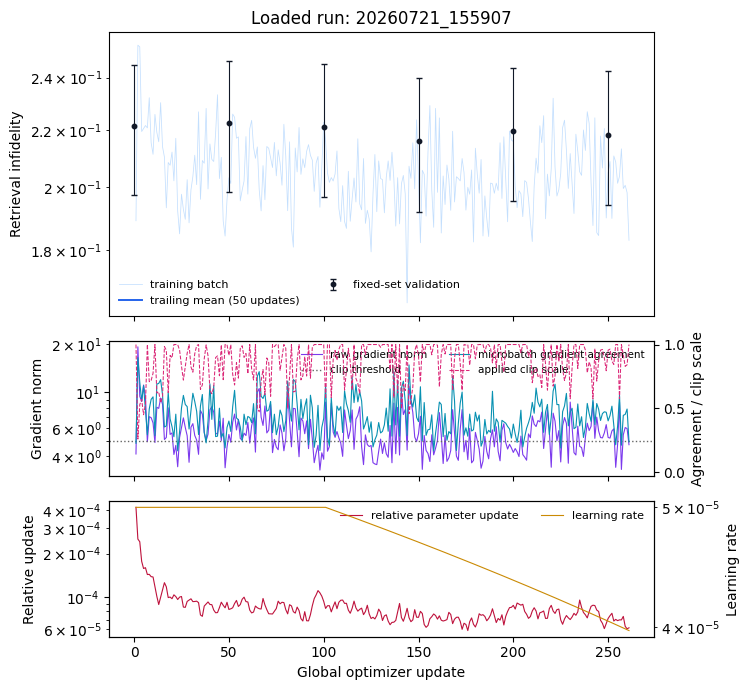

In [9]:
# Plot the training history stored with the loaded model.
def stagewise_trailing_mean(values, boundaries, window):
    """Trailing mean that never mixes samples from different stages."""
    values = np.asarray(values, dtype=float)
    result = np.full(values.shape, np.nan, dtype=float)
    boundaries = np.asarray(boundaries, dtype=int)
    for start, stop in zip(boundaries[:-1], boundaries[1:]):
        segment = values[start:stop]
        if len(segment) < window:
            continue
        rolling = np.convolve(
            segment,
            np.ones(window, dtype=float) / window,
            mode="valid",
        )
        result[start + window - 1:stop] = rolling
    return result


def perfect_single_rail_fidelity(feedback_steps):
    feedback_steps = np.asarray(feedback_steps, dtype=float)
    storage_time = 2.0 * t_drive + feedback_steps * (t_idle + t_drive)
    survival = np.exp(-storage_time / float(t1_cav))
    return (3.0 + 2.0 * np.sqrt(survival) + survival) / 6.0


loaded_history_candidates = [
    loaded_run_folder / "training_history.npz",
    loaded_run_folder / "memory_training_results.npz",
]
loaded_history_path = next(
    (path for path in loaded_history_candidates if path.exists()),
    None,
)

if loaded_history_path is None:
    print("No saved training history was found for:", loaded_run_folder)
else:
    with np.load(loaded_history_path, allow_pickle=False) as loaded_history:
        loaded_fidelity = np.asarray(
            loaded_history["mean_retrieval_fidelity_train"],
            dtype=float,
        )
        history_length = len(loaded_fidelity)
        loaded_boundaries = (
            np.asarray(loaded_history["stage_boundaries"], dtype=int)
            if "stage_boundaries" in loaded_history.files
            else np.asarray([0, history_length], dtype=int)
        )

        def loaded_array(name, default=np.nan):
            if name in loaded_history.files:
                values = np.asarray(loaded_history[name], dtype=float)
                if len(values) >= history_length:
                    return values[:history_length]
                return np.pad(
                    values,
                    (0, history_length - len(values)),
                    constant_values=default,
                )
            return np.full(history_length, default, dtype=float)

        loaded_gradient_norms = loaded_array("training_gradient_norms")
        loaded_gradient_agreements = loaded_array(
            "training_gradient_agreements"
        )
        loaded_clip_scales = loaded_array("training_clip_scales")
        loaded_relative_updates = loaded_array(
            "training_relative_update_norms"
        )
        loaded_learning_rates = loaded_array("training_learning_rates")

        if "stage_feedback_steps" in loaded_history.files:
            loaded_stage_feedback_steps = np.asarray(
                loaded_history["stage_feedback_steps"], dtype=int
            )
        elif "training_feedback_steps" in loaded_history.files:
            per_update_steps = np.asarray(
                loaded_history["training_feedback_steps"], dtype=int
            )
            loaded_stage_feedback_steps = np.asarray(
                [per_update_steps[start] for start in loaded_boundaries[:-1]],
                dtype=int,
            )
        else:
            loaded_stage_feedback_steps = None

        loaded_stage_batch_sizes = (
            np.asarray(loaded_history["stage_batch_sizes"], dtype=int)
            if "stage_batch_sizes" in loaded_history.files
            else None
        )
        loaded_stage_accumulation_steps = (
            np.asarray(
                loaded_history["stage_accumulation_steps"], dtype=int
            )
            if "stage_accumulation_steps" in loaded_history.files
            else None
        )

        if "baseline_feedback_steps" in loaded_history.files:
            loaded_baseline_steps = np.asarray(
                loaded_history["baseline_feedback_steps"], dtype=int
            )
            loaded_baseline_fidelities = np.asarray(
                loaded_history["baseline_fidelities"], dtype=float
            )
        elif (
            "training_feedback_steps" in loaded_history.files
            and "training_do_nothing_fidelities" in loaded_history.files
        ):
            per_update_baselines = np.asarray(
                loaded_history["training_do_nothing_fidelities"],
                dtype=float,
            )
            loaded_baseline_steps = loaded_stage_feedback_steps
            loaded_baseline_fidelities = np.asarray(
                [
                    per_update_baselines[start]
                    for start in loaded_boundaries[:-1]
                ],
                dtype=float,
            )
        else:
            loaded_baseline_steps = None
            loaded_baseline_fidelities = None

        loaded_validation_steps = (
            np.asarray(loaded_history["validation_global_steps"], dtype=int)
            if "validation_global_steps" in loaded_history.files
            else np.asarray([], dtype=int)
        )
        loaded_validation_fidelities = (
            np.asarray(
                loaded_history["validation_mean_fidelities"], dtype=float
            )
            if "validation_mean_fidelities" in loaded_history.files
            else np.asarray([], dtype=float)
        )
        loaded_validation_sems = (
            np.asarray(
                loaded_history["validation_fidelity_sems"], dtype=float
            )
            if "validation_fidelity_sems" in loaded_history.files
            else np.zeros_like(loaded_validation_fidelities)
        )

    loaded_steps = np.arange(1, len(loaded_fidelity) + 1)
    loaded_infidelity = 1.0 - loaded_fidelity
    loaded_rolling_fidelity = stagewise_trailing_mean(
        loaded_fidelity,
        loaded_boundaries,
        diagnostic_rolling_window,
    )

    fig, (ax, ax_grad, ax_update) = plt.subplots(
        3,
        1,
        figsize=(7.6, 7.0),
        sharex=True,
        gridspec_kw={"height_ratios": [2.3, 1.1, 1.1]},
    )

    raw_valid = np.isfinite(loaded_infidelity) & (loaded_infidelity > 0.0)
    ax.plot(
        loaded_steps[raw_valid],
        loaded_infidelity[raw_valid],
        color="#93c5fd",
        lw=0.55,
        alpha=0.55,
        label="training batch",
    )
    rolling_infidelity = 1.0 - loaded_rolling_fidelity
    rolling_valid = (
        np.isfinite(rolling_infidelity) & (rolling_infidelity > 0.0)
    )
    rolling_infidelity_for_plot = rolling_infidelity.copy()
    rolling_infidelity_for_plot[~rolling_valid] = np.nan
    ax.plot(
        loaded_steps,
        rolling_infidelity_for_plot,
        color="#2563eb",
        lw=1.4,
        label=f"trailing mean ({diagnostic_rolling_window} updates)",
    )

    if len(loaded_validation_steps):
        validation_infidelity = 1.0 - loaded_validation_fidelities
        validation_valid = (
            np.isfinite(validation_infidelity)
            & (validation_infidelity > 0.0)
        )
        ax.errorbar(
            loaded_validation_steps[validation_valid],
            validation_infidelity[validation_valid],
            yerr=loaded_validation_sems[validation_valid],
            fmt="o",
            ms=3.2,
            capsize=2,
            color="#111827",
            lw=0.8,
            label="fixed-set validation",
        )

    number_of_stages = min(
        len(loaded_boundaries) - 1,
        0 if loaded_stage_feedback_steps is None
        else len(loaded_stage_feedback_steps),
    )
    loaded_baseline_by_steps = (
        {
            int(feedback_steps): float(fidelity)
            for feedback_steps, fidelity in zip(
                loaded_baseline_steps,
                loaded_baseline_fidelities,
            )
        }
        if loaded_baseline_steps is not None
        else {}
    )

    for position in range(number_of_stages):
        start = loaded_boundaries[position]
        stop = loaded_boundaries[position + 1]
        feedback_steps = int(loaded_stage_feedback_steps[position])
        if feedback_steps in loaded_baseline_by_steps:
            ax.hlines(
                1.0 - loaded_baseline_by_steps[feedback_steps],
                start + 1,
                stop,
                color="#d97706",
                ls="--",
                lw=1.1,
                label=(
                    "do-nothing qubit-decay baseline"
                    if position == 0 else None
                ),
            )
        passive_fidelity = float(perfect_single_rail_fidelity(feedback_steps))
        ax.hlines(
            1.0 - passive_fidelity,
            start + 1,
            stop,
            color="#15803d",
            ls="-.",
            lw=1.1,
            label=(
                r"perfect single-rail storage, cavity $T_1$"
                if position == 0 else None
            ),
        )
        batch_label = (
            f", B={loaded_stage_batch_sizes[position]}"
            if loaded_stage_batch_sizes is not None
            and position < len(loaded_stage_batch_sizes)
            else ""
        )
        ax.text(
            0.5 * (start + stop),
            0.98,
            f"N={feedback_steps}{batch_label}",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=7.5,
        )

    gradient_valid = np.isfinite(loaded_gradient_norms) & (
        loaded_gradient_norms > 0.0
    )
    ax_grad.plot(
        loaded_steps[gradient_valid],
        loaded_gradient_norms[gradient_valid],
        color="#7c3aed",
        lw=0.8,
        label="raw gradient norm",
    )
    ax_grad.axhline(
        gradient_clip_norm,
        color="0.4",
        ls=":",
        lw=1.0,
        label="clip threshold",
    )
    ax_agreement = ax_grad.twinx()
    agreement_valid = np.isfinite(loaded_gradient_agreements)
    ax_agreement.plot(
        loaded_steps[agreement_valid],
        loaded_gradient_agreements[agreement_valid],
        color="#0891b2",
        lw=0.8,
        label="microbatch gradient agreement",
    )
    clip_valid = np.isfinite(loaded_clip_scales)
    ax_agreement.plot(
        loaded_steps[clip_valid],
        loaded_clip_scales[clip_valid],
        color="#db2777",
        ls="--",
        lw=0.75,
        label="applied clip scale",
    )
    if loaded_stage_accumulation_steps is not None:
        for position in range(
            min(number_of_stages, len(loaded_stage_accumulation_steps))
        ):
            ax_agreement.hlines(
                1.0 / loaded_stage_accumulation_steps[position],
                loaded_boundaries[position] + 1,
                loaded_boundaries[position + 1],
                color="0.65",
                ls=":",
                lw=0.7,
                label=(
                    "random-direction agreement"
                    if position == 0 else None
                ),
            )

    update_valid = np.isfinite(loaded_relative_updates) & (
        loaded_relative_updates > 0.0
    )
    ax_update.plot(
        loaded_steps[update_valid],
        loaded_relative_updates[update_valid],
        color="#be123c",
        lw=0.8,
        label="relative parameter update",
    )
    ax_lr = ax_update.twinx()
    lr_valid = np.isfinite(loaded_learning_rates) & (
        loaded_learning_rates > 0.0
    )
    ax_lr.plot(
        loaded_steps[lr_valid],
        loaded_learning_rates[lr_valid],
        color="#ca8a04",
        lw=0.8,
        label="learning rate",
    )

    for boundary in loaded_boundaries[1:-1]:
        for axis in (ax, ax_grad, ax_update):
            axis.axvline(boundary, color="0.75", ls=":", lw=0.8)

    ax.set_ylabel("Retrieval infidelity")
    ax.set_yscale("log")
    ax.set_title(f"Loaded run: {loaded_run_folder.name}")
    ax.legend(frameon=False, fontsize=8, ncol=2)

    ax_grad.set_ylabel("Gradient norm")
    ax_grad.set_yscale("log")
    ax_agreement.set_ylabel("Agreement / clip scale")
    ax_agreement.set_ylim(-0.03, 1.03)
    grad_handles, grad_labels = ax_grad.get_legend_handles_labels()
    agree_handles, agree_labels = ax_agreement.get_legend_handles_labels()
    ax_grad.legend(
        grad_handles + agree_handles,
        grad_labels + agree_labels,
        frameon=False,
        fontsize=7.5,
        ncol=2,
    )

    ax_update.set_xlabel("Global optimizer update")
    if np.any(update_valid):
        ax_update.set_ylabel("Relative update")
        ax_update.set_yscale("log")
    else:
        # Legacy histories do not contain this diagnostic. Matplotlib raises
        # during tight_layout if an empty axis is forced onto a log scale.
        ax_update.set_ylabel("Relative update")
        ax_update.set_yticks([])
        ax_update.text(
            0.01,
            0.5,
            "relative-update history unavailable in this legacy run",
            transform=ax_update.transAxes,
            ha="left",
            va="center",
            fontsize=8,
            color="0.4",
        )
    if np.any(lr_valid):
        ax_lr.set_ylabel("Learning rate")
        ax_lr.set_yscale("log")
    else:
        ax_lr.set_ylabel("Learning rate")
        ax_lr.set_yticks([])
    update_handles, update_labels = ax_update.get_legend_handles_labels()
    lr_handles, lr_labels = ax_lr.get_legend_handles_labels()
    ax_update.legend(
        update_handles + lr_handles,
        update_labels + lr_labels,
        frameon=False,
        fontsize=8,
        ncol=2,
    )

    fig.tight_layout()
    print("Loaded training history from:", loaded_history_path)


# Physical model

The physical model below is the same as in the original cavity-state stabilization notebook.

During the feedback latency, the measured qubit has already been reset to $|0\rangle$, so the cavity evolves under its ground-state self-Kerr and photon loss. During every driven pulse, the joint qubit--cavity Hamiltonian contains the dispersive coupling and the qubit-state-dependent cavity Kerr. Qubit relaxation, qubit dephasing, and cavity relaxation are applied throughout the pulse.


## Idle evolution: cavity self-Kerr and photon loss


In [10]:
def liouv_relax_channel(c):
    # Lindblad dissipator in the row-major vectorization convention.
    d = c.shape[0]
    I = identity(d)
    cdag_c = hconj(c) @ c

    L = tensor(c, c.conj())
    L -= 0.5 * tensor(cdag_c, I)
    L -= 0.5 * tensor(I, cdag_c.T)
    return L


def liouv_hamiltonian(H):
    # Hamiltonian Liouvillian -i[H,rho] in row-major vectorization.
    d = H.shape[0]
    I = identity(d)
    return -1j * (tensor(H, I) - tensor(I, H.T))


def make_cavity_idle_matrix(N_cav, t1_cav, t_idle):
    a = destroy(N_cav)
    adag = hconj(a)

    H_kerr_cav = 0.5 * K_cg * adag @ adag @ a @ a
    c_loss = a / jnp.sqrt(t1_cav)

    L_idle = liouv_hamiltonian(H_kerr_cav)
    L_idle += liouv_relax_channel(c_loss)
    return jsp.linalg.expm(L_idle * t_idle)


def make_idle_cav(N_cav, t1_qub, t2_qub, t1_cav, t_idle):
    # t1_qub and t2_qub are intentionally unused here: the qubit has been reset.
    idle_cav_matrix = make_cavity_idle_matrix(N_cav, t1_cav, t_idle)
    ket_g = basis(2)
    rho_g = ket_g @ hconj(ket_g)

    def idle_cav(rho):
        rho_cav = rho[:N_cav, :N_cav]
        rho_cav = (idle_cav_matrix @ rho_cav.reshape(-1, 1)).reshape(
            N_cav, N_cav
        )

        rho_out = tensor(rho_g, rho_cav)
        return rho_out / jnp.trace(rho_out)

    return idle_cav


## Driven joint qubit--cavity evolution with relaxation


In [11]:
mu_qub = 20.0
mu_cav = 20.0


def build_drive_htree(N_cav, chi, e_qub, e_cav):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a

    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))

    H_disp = (chi / 2) * n_phot @ (one - sigz)

    proj_g = 0.5 * (one + sigz)
    proj_e = 0.5 * (one - sigz)
    kerr_op = adag @ adag @ a @ a
    H_kerr = 0.5 * (K_cg * proj_g + K_ce * proj_e) @ kerr_op

    H_drift = H_disp + H_kerr

    return [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],
        [mu_cav * adag, 1j * jnp.conj(e_cav), 1, 1],
    ]


def get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt):
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)
    return evol_hdt_exp(hmat_from_htree(htree), dt)


def liouv_relax_channel_qubit_cav(c):
    L = tensor(c, c.conj())
    L -= 0.5 * tensor(hconj(c) @ c, identity(len(c)))
    L -= 0.5 * tensor(identity(len(c)), (hconj(c) @ c).T)
    return L


def eval_idling_matrix(c_ops, t):
    L = sum(liouv_relax_channel_qubit_cav(c) for c in c_ops)
    return jsp.linalg.expm(L * t)


def build_c_ops(N_cav, t1_qub, t2_qub, t1_cav):
    t_phi_qub = 1 / ((1 / t2_qub) - (1 / t1_qub) / 2)

    sigm = tensor(sigma.m, identity(N_cav))
    sigz = tensor(sigma.z, identity(N_cav))
    a = tensor(identity(2), destroy(N_cav))

    return [
        sigm / jnp.sqrt(t1_qub),
        sigz / jnp.sqrt(2 * t_phi_qub),
        a / jnp.sqrt(t1_cav),
    ]


def make_idle_dt(N_cav, t1_qub, t2_qub, t1_cav, t):
    idling_matrix = eval_idling_matrix(
        build_c_ops(N_cav, t1_qub, t2_qub, t1_cav), t
    )

    def idle_dt(rho):
        rho_vec = idling_matrix @ rho.reshape(-1, 1)
        return rho_vec.reshape(rho.shape)

    return idle_dt


def make_drive_with_relax(N_cav, chi, t1_qub, t2_qub, t1_cav, dt_idle):
    idle_after_drive_dt = make_idle_dt(
        N_cav, t1_qub, t2_qub, t1_cav, dt_idle
    )

    def drive_with_relax(rho_init, es_qub, es_cav, dts):
        def one_interval(rho, fields_and_dt):
            e_qub, e_cav, dt = fields_and_dt
            U = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
            rho = U @ rho @ hconj(U)
            rho = idle_after_drive_dt(rho)
            return rho, None

        rho_final, _ = jax.lax.scan(
            one_interval, rho_init, [es_qub, es_cav, dts]
        )
        return rho_final

    return drive_with_relax


def ctrl_from_coeffs(ctrl_coeffs, bsplines):
    controls = ctrl_coeffs @ bsplines
    e_qub = controls[0] + 1j * controls[1]
    e_cav = controls[2] + 1j * controls[3]
    return e_qub, e_cav


## Projective readout and qubit reset

For the sampled outcome $y\in\{0,1\}$, the corresponding diagonal qubit block is selected with its Born probability and normalized. The qubit is then reset to $|0\rangle$ while the conditional cavity block is retained. The binary controller input is $m_k=+1$ for outcome $0$ and $m_k=-1$ for outcome $1$.

There is no additional readout-induced Gaussian dephasing channel in this version: `measure_sz` implements projection and reset only.


In [12]:
def measure_sz(key, rho_init):
    probs = rho_init.diagonal().reshape(2, -1).sum(axis=1).real
    outcome_index = jax.random.choice(key, 2, p=probs)
    prob = probs[outcome_index]

    rho_cav = jnp.where(
        outcome_index == 0,
        rho_init[: rho_init.shape[0] // 2, : rho_init.shape[1] // 2],
        rho_init[rho_init.shape[0] // 2 :, rho_init.shape[1] // 2 :],
    )

    ket_g = basis(2)
    rho_out = tensor(ket_g @ hconj(ket_g), rho_cav)
    rho_out /= jnp.trace(rho_out)

    measurement = 1 - 2 * outcome_index
    return measurement, prob, rho_out


## Numerical dimensions, timing, and quadratic B-spline basis


In [13]:
ndt_drive = 230
N_cav = 25

t_drive_edges = jnp.linspace(0.0, t_drive, ndt_drive + 1)
t_drive_mids = 0.5 * (t_drive_edges[1:] + t_drive_edges[:-1])
t_drive_intvs = t_drive_edges[1:] - t_drive_edges[:-1]

bspline_builder = setup_bspline_builder(
    0.0,
    t_drive_edges[-1],
    n_knots,
    k,
    skip_left,
    skip_right,
)
bsplns_mids = bspline_builder(t_drive_mids)
bsplns_edges = bspline_builder(t_drive_edges)

print("cavity cutoff:", N_cav)
print("drive integration intervals:", ndt_drive)
print("B-spline degree:", k)
print("number of coefficients per quadrature:", num_bspln)
print("single B-spline support:", L_ns, "ns")
print("encoding/correction/decoding pulse duration:", T_ns_hw, "ns")
print("maximum simultaneous B-splines:", k + 1)


cavity cutoff: 25
drive integration intervals: 230
B-spline degree: 2
number of coefficients per quadrature: 20
single B-spline support: 192 ns
encoding/correction/decoding pulse duration: 1408 ns
maximum simultaneous B-splines: 3


# End-to-end quantum-memory trajectory

The initial state is

$$
\rho_0(\psi)=|\psi\rangle\!\langle\psi|\otimes|0\rangle_c\!\langle0|.
$$

The trainable encoding pulse is applied first. Each feedback step then performs, in order:

1. projective qubit measurement and qubit reset, with no added readout-induced dephasing;
2. cavity evolution during the feedback latency;
3. GRU update from the binary measurement outcome;
4. measurement-conditioned joint qubit--cavity correction pulse.

After $N$ steps, the trainable decoding pulse is applied directly to the final joint state. No measurement or reset is inserted between the final correction and decoding. The output cavity is traced out and the retrieval fidelity is

$$
F_{\mathrm{ret}}(\psi,\mathbf m)
=\langle\psi|\rho_{q,\mathrm{out}}|\psi\rangle.
$$

The optimized reward additionally contains the weak energy and pulse-envelope penalties defined below.


In [14]:
def sample_haar_qubit(key):
    # Sample a pure qubit uniformly from the Bloch sphere.
    key_z, key_phi = jax.random.split(key)
    z = jax.random.uniform(key_z, minval=-1.0, maxval=1.0)
    phi = 2 * jnp.pi * jax.random.uniform(key_phi)

    alpha = jnp.sqrt((1.0 + z) / 2.0)
    beta = jnp.exp(1j * phi) * jnp.sqrt((1.0 - z) / 2.0)
    psi = alpha * basis(2, 0) + beta * basis(2, 1)

    bloch = jnp.array(
        [
            2 * jnp.real(jnp.conj(alpha) * beta),
            2 * jnp.imag(jnp.conj(alpha) * beta),
            jnp.abs(alpha) ** 2 - jnp.abs(beta) ** 2,
        ]
    )
    return psi, bloch


def reduced_qubit_state(rho_joint, N_cav):
    rho_tensor = rho_joint.reshape(2, N_cav, 2, N_cav)
    return jnp.trace(rho_tensor, axis1=1, axis2=3)


def qubit_state_fidelity(rho_qubit, psi_target):
    return jnp.real((hconj(psi_target) @ rho_qubit @ psi_target)[0, 0])


def qubit_bloch_vector(rho_qubit):
    return jnp.array(
        [
            2 * jnp.real(rho_qubit[0, 1]),
            -2 * jnp.imag(rho_qubit[0, 1]),
            jnp.real(rho_qubit[0, 0] - rho_qubit[1, 1]),
        ]
    )


def do_nothing_qubit_decay_fidelity(
    num_feedback_steps,
    include_encoding_decoding_time=True,
):
    # Exact Haar-average fidelity if the state is left in the decaying qubit.
    total_wait_time = num_feedback_steps * (t_idle + t_drive)
    if include_encoding_decoding_time:
        total_wait_time += 2 * t_drive

    t_phi_qub = 1 / ((1 / t2_qub) - (1 / t1_qub) / 2)
    qubit_liouvillian = liouv_relax_channel(
        sigma.m / jnp.sqrt(t1_qub)
    )
    qubit_liouvillian += liouv_relax_channel(
        sigma.z / jnp.sqrt(2 * t_phi_qub)
    )
    qubit_decay_channel = jsp.linalg.expm(
        qubit_liouvillian * total_wait_time
    )

    ket_0 = basis(2, 0)
    ket_1 = basis(2, 1)
    cardinal_states = [
        ket_0,
        ket_1,
        (ket_0 + ket_1) / jnp.sqrt(2),
        (ket_0 - ket_1) / jnp.sqrt(2),
        (ket_0 + 1j * ket_1) / jnp.sqrt(2),
        (ket_0 - 1j * ket_1) / jnp.sqrt(2),
    ]

    fidelities = []
    for psi_input in cardinal_states:
        rho_input = psi_input @ hconj(psi_input)
        rho_output = (
            qubit_decay_channel @ rho_input.reshape(-1, 1)
        ).reshape(2, 2)
        fidelities.append(
            qubit_state_fidelity(rho_output, psi_input)
        )

    # The six Pauli eigenstates form a qubit state 2-design, so their mean
    # is the exact Haar-average fidelity for this linear channel.
    return jnp.mean(jnp.asarray(fidelities)), total_wait_time


def cavity_mean_photon(rho_joint, N_cav):
    joint_populations = jnp.real(jnp.diag(rho_joint)).reshape(2, N_cav)
    cavity_populations = joint_populations.sum(axis=0)
    return jnp.sum(jnp.arange(N_cav) * cavity_populations)


def smooth_positive_part(value, width):
    return width * jax.nn.softplus(value / width)


def cavity_energy_cost(mean_photon):
    excess = smooth_positive_part(
        mean_photon - photon_soft_limit,
        photon_soft_width,
    )
    return (excess / photon_soft_limit) ** 2


def pulse_envelope_cost(e_qub, e_cav):
    qubit_excess = smooth_positive_part(
        jnp.abs(e_qub) - qubit_envelope_soft_limit,
        pulse_soft_width,
    )
    cavity_excess = smooth_positive_part(
        jnp.abs(e_cav) - cavity_envelope_soft_limit,
        pulse_soft_width,
    )
    qubit_cost = jnp.mean(
        (qubit_excess / qubit_envelope_soft_limit) ** 2
    )
    cavity_cost = jnp.mean(
        (cavity_excess / cavity_envelope_soft_limit) ** 2
    )
    return 0.5 * (qubit_cost + cavity_cost)


## One recurrent feedback step


In [15]:
def make_feedback_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle):
    idle_cav = make_idle_cav(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
    drive = make_drive_with_relax(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        t_drive_intvs[0],
    )

    def feedback_step(key, rho, train_state, params, carry):
        measurement, prob, rho = measure_sz(key, rho)
        rho = idle_cav(rho)

        rnn_input = jnp.array([measurement], dtype=float)
        carry, ctrl_coeffs = apply_feedback_policy(
            train_state, params, carry, rnn_input
        )

        e_qub, e_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)
        pulse_cost = pulse_envelope_cost(e_qub, e_cav)
        rho = drive(rho, e_qub, e_cav, t_drive_intvs)
        mean_photon = cavity_mean_photon(rho, N_cav)
        return (
            rho,
            carry,
            measurement,
            prob,
            mean_photon,
            pulse_cost,
        )

    return feedback_step


## Encoding, repeated feedback, decoding, and terminal fidelity


In [16]:
def make_quantum_memory_trajectories(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
):
    feedback_step = make_feedback_step(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
    )
    drive = make_drive_with_relax(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        t_drive_intvs[0],
    )

    def trajectory_from_state(
        key,
        train_state,
        params,
        num_feedback_steps,
        psi_input,
    ):
        # Preserve the previous key splitting convention for trajectory
        # reproducibility, but use one shared trainable initial carry.
        _, key_scan = jax.random.split(key)
        carry = params["initial_carry"]

        psi_initial = tensor(psi_input, basis(N_cav, 0))
        rho = psi_initial @ hconj(psi_initial)

        e_qub, e_cav = ctrl_from_coeffs(
            params["encoding_coeffs"], bsplns_mids
        )
        encoding_pulse_cost = pulse_envelope_cost(e_qub, e_cav)
        rho = drive(rho, e_qub, e_cav, t_drive_intvs)
        encoding_mean_photon = cavity_mean_photon(rho, N_cav)

        def one_feedback_step(scan_carry, _):
            key_step, rho_step, carry_step = scan_carry
            key_step, subkey = jax.random.split(key_step)

            (
                rho_step,
                carry_step,
                measurement,
                prob,
                mean_photon,
                pulse_cost,
            ) = feedback_step(
                subkey,
                rho_step,
                train_state,
                params,
                carry_step,
            )
            return (
                key_step,
                rho_step,
                carry_step,
            ), (
                measurement,
                prob,
                mean_photon,
                pulse_cost,
            )

        (
            (_, rho, carry),
            (
                measurements,
                probs,
                feedback_mean_photons,
                feedback_pulse_costs,
            ),
        ) = jax.lax.scan(
            one_feedback_step,
            (key_scan, rho, carry),
            length=num_feedback_steps,
        )

        e_qub, e_cav = ctrl_from_coeffs(
            params["decoding_coeffs"], bsplns_mids
        )
        decoding_pulse_cost = pulse_envelope_cost(e_qub, e_cav)
        rho = drive(rho, e_qub, e_cav, t_drive_intvs)
        decoding_mean_photon = cavity_mean_photon(rho, N_cav)

        rho_qubit_out = reduced_qubit_state(rho, N_cav)
        retrieval_fidelity = qubit_state_fidelity(
            rho_qubit_out, psi_input
        )

        mean_photons = jnp.concatenate(
            (
                jnp.asarray([encoding_mean_photon]),
                feedback_mean_photons,
                jnp.asarray([decoding_mean_photon]),
            )
        )
        pulse_costs = jnp.concatenate(
            (
                jnp.asarray([encoding_pulse_cost]),
                feedback_pulse_costs,
                jnp.asarray([decoding_pulse_cost]),
            )
        )
        energy_cost = jnp.mean(cavity_energy_cost(mean_photons))
        pulse_cost = jnp.mean(pulse_costs)
        max_mean_photon = jnp.max(mean_photons)

        return (
            retrieval_fidelity,
            measurements,
            probs,
            rho_qubit_out,
            energy_cost,
            pulse_cost,
            max_mean_photon,
        )

    def random_trajectory(
        key, train_state, params, num_feedback_steps
    ):
        key_input, key_dynamics = jax.random.split(key)
        psi_input, input_bloch = sample_haar_qubit(key_input)

        trajectory_output = trajectory_from_state(
            key_dynamics,
            train_state,
            params,
            num_feedback_steps,
            psi_input,
        )
        (
            retrieval_fidelity,
            measurements,
            probs,
            rho_qubit_out,
            energy_cost,
            pulse_cost,
            max_mean_photon,
        ) = trajectory_output
        return (
            retrieval_fidelity,
            measurements,
            probs,
            input_bloch,
            rho_qubit_out,
            energy_cost,
            pulse_cost,
            max_mean_photon,
        )

    return random_trajectory, trajectory_from_state


# Regularized feedback-GRAPE gradient

Let $\mathbf m=(m_1,\ldots,m_N)$ denote the sampled measurement record and let $P_\theta(\mathbf m|\psi)$ be its probability. For one trajectory define

$$
R_\lambda
=F_{\mathrm{ret}}
-\lambda_n C_n
-\lambda_u C_u,
$$

where $C_n$ is the mean smooth excess-energy cost evaluated after encoding, every feedback pulse, and decoding, while $C_u$ is the corresponding mean smooth envelope-amplitude cost. Both costs are approximately zero below their configurable soft limits. The optimized objective is

$$
J_\lambda(\theta)=
\mathbb E_{\psi\sim\mathrm{Haar}}
\mathbb E_{\mathbf m\sim P_\theta(\cdot|\psi)}
\left[R_\lambda(\psi,\mathbf m)\right].
$$

The feedback-GRAPE estimator is applied to the **complete regularized reward**,

$$
\nabla_\theta J_\lambda
=\mathbb E_{\psi,\mathbf m}
\left[
\nabla_\theta R_\lambda
+R_\lambda\nabla_\theta\log P_\theta(\mathbf m|\psi)
\right].
$$

This includes direct automatic-differentiation gradients through the physical costs and the score-function contribution due to the parameter-dependent measurement record. The implementation uses the surrogate

$$
R_\lambda+
\operatorname{stopgrad}(R_\lambda)
\sum_{k=1}^{N}\log p_\theta(m_k|m_{<k},\psi).
$$

The raw retrieval fidelity, regularized reward, energy cost, pulse cost, and maximum mean photon number are all reported separately.


In [17]:
def make_trajectory_with_rewgrad(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
):
    random_trajectory, _ = make_quantum_memory_trajectories(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
    )

    def trajectory_with_rewgrad(key, train_state, num_feedback_steps):
        def objective_for_one_sample(params):
            trajectory_output = random_trajectory(
                key,
                train_state,
                params,
                num_feedback_steps,
            )
            (
                retrieval_fidelity,
                _,
                probs,
                _,
                _,
                energy_cost,
                pulse_cost,
                max_mean_photon,
            ) = trajectory_output

            fidelity_reward = jnp.clip(
                jnp.real(retrieval_fidelity), 0.0, 1.0
            )
            regularized_reward = (
                fidelity_reward
                - energy_penalty_weight * energy_cost
                - pulse_penalty_weight * pulse_cost
            )
            safe_probs = jnp.clip(probs, 1e-8, 1.0)
            log_record_probability = jnp.log(safe_probs).sum()

            feedback_grape_surrogate = (
                regularized_reward
                + jax.lax.stop_gradient(regularized_reward)
                * log_record_probability
            )
            auxiliary = (
                fidelity_reward,
                regularized_reward,
                energy_cost,
                pulse_cost,
                max_mean_photon,
            )
            return feedback_grape_surrogate, auxiliary

        gradient_function = jax.grad(
            objective_for_one_sample, has_aux=True
        )
        reward_gradient, auxiliary = gradient_function(train_state.params)
        return (reward_gradient, *auxiliary)

    return trajectory_with_rewgrad


## Vectorized training, diagnostics, and testing batches

Each optimizer update averages trajectory gradients over several independent Haar-random microbatches. Besides the regularized feedback-GRAPE gradient, the compiled training function returns the sampling error of the raw batch fidelity, regularized reward, separate energy and pulse costs, the largest trajectory mean photon number, raw gradient norm, agreement between microbatch gradients, clipping scale, and relative parameter-update norm.

The raw fidelity remains the primary memory metric. The regularized reward shows what the optimizer actually maximizes, while the two cost histories reveal whether the constraints are active and prevent a hidden trade of retrieval performance for smaller pulses.


In [18]:
def make_train_on_batch(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    batch_size,
    num_feedback_steps,
    gradient_accumulation_steps,
):
    trajectory_with_rewgrad = make_trajectory_with_rewgrad(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
    )
    batched_trajectory_with_rewgrad = jax.vmap(
        trajectory_with_rewgrad, in_axes=(0, None, None)
    )
    effective_batch_size = batch_size * gradient_accumulation_steps

    @jax.jit
    def train_on_batch(key, train_state):
        microbatch_keys = jax.random.split(
            key, gradient_accumulation_steps
        )
        zero_reward_gradient = jax.tree.map(
            jnp.zeros_like, train_state.params
        )

        initial_accumulator = (
            zero_reward_gradient,
            jnp.asarray(0.0),
            jnp.asarray(0.0),
            jnp.asarray(0.0),
            jnp.asarray(0.0),
            jnp.asarray(0.0),
            jnp.asarray(0.0),
            jnp.asarray(0.0),
        )

        def accumulate_one_microbatch(accumulator, microbatch_key):
            (
                reward_gradient_sum,
                microbatch_gradient_norm_sq_sum,
                fidelity_sum,
                fidelity_sq_sum,
                regularized_reward_sum,
                energy_cost_sum,
                pulse_cost_sum,
                max_mean_photon,
            ) = accumulator
            trajectory_keys = jax.random.split(
                microbatch_key, batch_size
            )

            (
                reward_gradients,
                retrieval_fidelities,
                regularized_rewards,
                energy_costs,
                pulse_costs,
                max_mean_photons,
            ) = batched_trajectory_with_rewgrad(
                trajectory_keys,
                train_state,
                num_feedback_steps,
            )

            mean_reward_gradient = jax.tree.map(
                lambda x: x.mean(axis=0), reward_gradients
            )
            reward_gradient_sum = jax.tree.map(
                lambda accumulated, current: accumulated + current,
                reward_gradient_sum,
                mean_reward_gradient,
            )
            microbatch_gradient_norm_sq_sum += (
                optax.global_norm(mean_reward_gradient) ** 2
            )
            fidelity_sum += jnp.sum(retrieval_fidelities)
            fidelity_sq_sum += jnp.sum(retrieval_fidelities ** 2)
            regularized_reward_sum += jnp.sum(regularized_rewards)
            energy_cost_sum += jnp.sum(energy_costs)
            pulse_cost_sum += jnp.sum(pulse_costs)
            max_mean_photon = jnp.maximum(
                max_mean_photon, jnp.max(max_mean_photons)
            )

            return (
                reward_gradient_sum,
                microbatch_gradient_norm_sq_sum,
                fidelity_sum,
                fidelity_sq_sum,
                regularized_reward_sum,
                energy_cost_sum,
                pulse_cost_sum,
                max_mean_photon,
            ), None

        (
            reward_gradient_sum,
            microbatch_gradient_norm_sq_sum,
            fidelity_sum,
            fidelity_sq_sum,
            regularized_reward_sum,
            energy_cost_sum,
            pulse_cost_sum,
            max_mean_photon,
        ), _ = jax.lax.scan(
            accumulate_one_microbatch,
            initial_accumulator,
            microbatch_keys,
        )

        mean_reward_gradient = jax.tree.map(
            lambda x: x / gradient_accumulation_steps,
            reward_gradient_sum,
        )
        loss_gradient = jax.tree.map(lambda x: -x, mean_reward_gradient)
        raw_gradient_norm = optax.global_norm(loss_gradient)

        summed_gradient_norm_sq = optax.global_norm(
            reward_gradient_sum
        ) ** 2
        gradient_agreement = summed_gradient_norm_sq / (
            gradient_accumulation_steps
            * microbatch_gradient_norm_sq_sum
            + 1.0e-20
        )
        clip_scale = jnp.minimum(
            1.0,
            gradient_clip_norm / (raw_gradient_norm + 1.0e-20),
        )

        mean_fidelity = fidelity_sum / effective_batch_size
        sample_variance = jnp.maximum(
            (
                fidelity_sq_sum
                - effective_batch_size * mean_fidelity ** 2
            )
            / (effective_batch_size - 1),
            0.0,
        )
        fidelity_sem = jnp.sqrt(sample_variance / effective_batch_size)
        mean_regularized_reward = (
            regularized_reward_sum / effective_batch_size
        )
        mean_energy_cost = energy_cost_sum / effective_batch_size
        mean_pulse_cost = pulse_cost_sum / effective_batch_size

        old_params = train_state.params
        new_train_state = train_state.apply_gradients(grads=loss_gradient)
        parameter_delta = jax.tree.map(
            lambda new, old: new - old,
            new_train_state.params,
            old_params,
        )
        relative_update_norm = optax.global_norm(parameter_delta) / (
            optax.global_norm(old_params) + 1.0e-20
        )

        return (
            new_train_state,
            mean_fidelity,
            fidelity_sem,
            mean_regularized_reward,
            mean_energy_cost,
            mean_pulse_cost,
            max_mean_photon,
            raw_gradient_norm,
            gradient_agreement,
            clip_scale,
            relative_update_norm,
        )

    return train_on_batch


def make_test_on_batch(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    batch_size,
    num_feedback_steps,
):
    random_trajectory, _ = make_quantum_memory_trajectories(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
    )
    batched_random_trajectory = jax.vmap(
        random_trajectory, in_axes=(0, None, None, None)
    )

    @jax.jit
    def test_on_batch(key, train_state):
        keys = jax.random.split(key, batch_size)
        return batched_random_trajectory(
            keys,
            train_state,
            train_state.params,
            num_feedback_steps,
        )

    return test_on_batch


# Continue training the regularized end-to-end memory

The active curriculum continues at $N=11$. With `N_cav=25` and `ndt_drive=230`, the training and validation microbatches are reduced by approximately the inverse discretization ratio relative to the tested 200-interval run. Gradient-accumulation counts are deliberately unchanged.

At every stage, one fixed set of 56 Haar-random states is evaluated before training and every 50 updates. The progress bar reports raw fidelity `F`, regularized reward `R`, energy and pulse costs, maximum mean photon number, rolling fidelity, fixed-set validation, and gradient/update diagnostics. History and complete checkpoints (parameters, Adam state, PRNG key, and trainable initial GRU carry) are saved after every completed stage.


In [19]:
history_path = run_folder / "training_history.npz"


def padded_history_array(saved_history, name, length, default=np.nan):
    if name not in saved_history.files:
        return [float(default)] * length
    values = np.asarray(saved_history[name], dtype=float)[:length].tolist()
    values.extend([float(default)] * (length - len(values)))
    return values


if load_mode == "full_state" and history_path.exists():
    with np.load(history_path, allow_pickle=False) as saved_history:
        # A full-state checkpoint marks the last completely saved stage.
        mean_retrieval_fidelity_train = np.asarray(
            saved_history["mean_retrieval_fidelity_train"], dtype=float
        )[:global_step].tolist()
        history_length = len(mean_retrieval_fidelity_train)
        training_fidelity_sems = padded_history_array(
            saved_history, "training_fidelity_sems", history_length
        )
        training_gradient_norms = padded_history_array(
            saved_history, "training_gradient_norms", history_length
        )
        training_gradient_agreements = padded_history_array(
            saved_history,
            "training_gradient_agreements",
            history_length,
        )
        training_clip_scales = padded_history_array(
            saved_history, "training_clip_scales", history_length
        )
        training_relative_update_norms = padded_history_array(
            saved_history,
            "training_relative_update_norms",
            history_length,
        )
        training_learning_rates = padded_history_array(
            saved_history, "training_learning_rates", history_length
        )
        training_regularized_rewards = padded_history_array(
            saved_history, "training_regularized_rewards", history_length
        )
        training_energy_costs = padded_history_array(
            saved_history, "training_energy_costs", history_length
        )
        training_pulse_costs = padded_history_array(
            saved_history, "training_pulse_costs", history_length
        )
        training_max_mean_photons = padded_history_array(
            saved_history, "training_max_mean_photons", history_length
        )

        stage_boundaries = [
            int(boundary)
            for boundary in saved_history["stage_boundaries"]
            if int(boundary) <= global_step
        ]
        num_completed_stages = max(0, len(stage_boundaries) - 1)

        if "stage_feedback_steps" in saved_history.files:
            stage_feedback_steps = saved_history[
                "stage_feedback_steps"
            ][:num_completed_stages].astype(int).tolist()
            stage_batch_sizes = saved_history[
                "stage_batch_sizes"
            ][:num_completed_stages].astype(int).tolist()
            stage_accumulation_steps = saved_history[
                "stage_accumulation_steps"
            ][:num_completed_stages].astype(int).tolist()
            stage_effective_batch_sizes = saved_history[
                "stage_effective_batch_sizes"
            ][:num_completed_stages].astype(int).tolist()
        else:
            stage_starts = stage_boundaries[:-1]
            stage_feedback_steps = [
                int(saved_history["training_feedback_steps"][start])
                for start in stage_starts
            ]
            stage_batch_sizes = [
                int(saved_history["training_batch_sizes"][start])
                for start in stage_starts
            ]
            stage_accumulation_steps = [
                int(saved_history["training_accumulation_steps"][start])
                for start in stage_starts
            ]
            stage_effective_batch_sizes = [
                int(saved_history["training_effective_batch_sizes"][start])
                for start in stage_starts
            ]

        if "baseline_feedback_steps" in saved_history.files:
            baseline_feedback_steps = saved_history[
                "baseline_feedback_steps"
            ].astype(int).tolist()
            baseline_fidelities = saved_history[
                "baseline_fidelities"
            ].astype(float).tolist()
            baseline_wait_times = saved_history[
                "baseline_wait_times"
            ].astype(float).tolist()
        else:
            baseline_feedback_steps = []
            baseline_fidelities = []
            baseline_wait_times = []
            legacy_baselines = saved_history[
                "training_do_nothing_fidelities"
            ]
            for stage_start, feedback_steps in zip(
                stage_boundaries[:-1], stage_feedback_steps
            ):
                if feedback_steps in baseline_feedback_steps:
                    continue
                baseline_feedback_steps.append(feedback_steps)
                baseline_fidelities.append(
                    float(legacy_baselines[stage_start])
                )
                wait_time = feedback_steps * (t_idle + t_drive)
                if baseline_include_encoding_decoding_time:
                    wait_time += 2.0 * t_drive
                baseline_wait_times.append(float(wait_time))

        if "validation_global_steps" in saved_history.files:
            validation_global_steps_array = np.asarray(
                saved_history["validation_global_steps"], dtype=int
            )
            validation_keep = validation_global_steps_array <= global_step
            validation_global_steps = validation_global_steps_array[
                validation_keep
            ].tolist()
            validation_stage_indices = np.asarray(
                saved_history["validation_stage_indices"], dtype=int
            )[validation_keep].tolist()
            validation_feedback_steps = np.asarray(
                saved_history["validation_feedback_steps"], dtype=int
            )[validation_keep].tolist()
            validation_mean_fidelities = np.asarray(
                saved_history["validation_mean_fidelities"], dtype=float
            )[validation_keep].tolist()
            validation_fidelity_sems = np.asarray(
                saved_history["validation_fidelity_sems"], dtype=float
            )[validation_keep].tolist()
            num_validation_points = len(validation_global_steps)

            def load_validation_metric(name):
                if name not in saved_history.files:
                    return [float("nan")] * num_validation_points
                return np.asarray(
                    saved_history[name], dtype=float
                )[validation_keep].tolist()

            validation_regularized_rewards = load_validation_metric(
                "validation_regularized_rewards"
            )
            validation_energy_costs = load_validation_metric(
                "validation_energy_costs"
            )
            validation_pulse_costs = load_validation_metric(
                "validation_pulse_costs"
            )
            validation_max_mean_photons = load_validation_metric(
                "validation_max_mean_photons"
            )
        else:
            validation_global_steps = []
            validation_stage_indices = []
            validation_feedback_steps = []
            validation_mean_fidelities = []
            validation_fidelity_sems = []
            validation_regularized_rewards = []
            validation_energy_costs = []
            validation_pulse_costs = []
            validation_max_mean_photons = []
else:
    mean_retrieval_fidelity_train = []
    training_fidelity_sems = []
    training_gradient_norms = []
    training_gradient_agreements = []
    training_clip_scales = []
    training_relative_update_norms = []
    training_learning_rates = []
    training_regularized_rewards = []
    training_energy_costs = []
    training_pulse_costs = []
    training_max_mean_photons = []

    stage_boundaries = [global_step]
    stage_feedback_steps = []
    stage_batch_sizes = []
    stage_accumulation_steps = []
    stage_effective_batch_sizes = []

    baseline_feedback_steps = []
    baseline_fidelities = []
    baseline_wait_times = []

    validation_global_steps = []
    validation_stage_indices = []
    validation_feedback_steps = []
    validation_mean_fidelities = []
    validation_fidelity_sems = []
    validation_regularized_rewards = []
    validation_energy_costs = []
    validation_pulse_costs = []
    validation_max_mean_photons = []


def save_current_history():
    np.savez(
        history_path,
        history_schema_version=np.asarray(4),
        mean_retrieval_fidelity_train=np.asarray(
            mean_retrieval_fidelity_train
        ),
        training_fidelity_sems=np.asarray(training_fidelity_sems),
        training_gradient_norms=np.asarray(training_gradient_norms),
        training_gradient_agreements=np.asarray(
            training_gradient_agreements
        ),
        training_clip_scales=np.asarray(training_clip_scales),
        training_relative_update_norms=np.asarray(
            training_relative_update_norms
        ),
        training_learning_rates=np.asarray(training_learning_rates),
        training_regularized_rewards=np.asarray(
            training_regularized_rewards
        ),
        training_energy_costs=np.asarray(training_energy_costs),
        training_pulse_costs=np.asarray(training_pulse_costs),
        training_max_mean_photons=np.asarray(
            training_max_mean_photons
        ),
        stage_boundaries=np.asarray(stage_boundaries),
        stage_feedback_steps=np.asarray(stage_feedback_steps),
        stage_batch_sizes=np.asarray(stage_batch_sizes),
        stage_accumulation_steps=np.asarray(stage_accumulation_steps),
        stage_effective_batch_sizes=np.asarray(
            stage_effective_batch_sizes
        ),
        baseline_feedback_steps=np.asarray(baseline_feedback_steps),
        baseline_fidelities=np.asarray(baseline_fidelities),
        baseline_wait_times=np.asarray(baseline_wait_times),
        validation_global_steps=np.asarray(validation_global_steps),
        validation_stage_indices=np.asarray(validation_stage_indices),
        validation_feedback_steps=np.asarray(validation_feedback_steps),
        validation_mean_fidelities=np.asarray(
            validation_mean_fidelities
        ),
        validation_fidelity_sems=np.asarray(validation_fidelity_sems),
        validation_regularized_rewards=np.asarray(
            validation_regularized_rewards
        ),
        validation_energy_costs=np.asarray(validation_energy_costs),
        validation_pulse_costs=np.asarray(validation_pulse_costs),
        validation_max_mean_photons=np.asarray(
            validation_max_mean_photons
        ),
    )


baseline_cache = {
    int(feedback_steps): (float(fidelity), float(wait_time))
    for feedback_steps, fidelity, wait_time in zip(
        baseline_feedback_steps,
        baseline_fidelities,
        baseline_wait_times,
    )
}


for stage_index in range(start_stage_index, len(training_curriculum)):
    stage = training_curriculum[stage_index]
    num_feedback_steps_train = stage["num_feedback_steps"]
    batch_size = stage["batch_size"]
    gradient_accumulation_steps = stage["gradient_accumulation_steps"]
    effective_batch_size = batch_size * gradient_accumulation_steps
    num_stage_batches = stage["num_batches"]

    if num_feedback_steps_train not in baseline_cache:
        do_nothing_fidelity, baseline_wait_time = (
            do_nothing_qubit_decay_fidelity(
                num_feedback_steps_train,
                include_encoding_decoding_time=(
                    baseline_include_encoding_decoding_time
                ),
            )
        )
        baseline_cache[num_feedback_steps_train] = (
            float(do_nothing_fidelity),
            float(baseline_wait_time),
        )
        baseline_feedback_steps.append(num_feedback_steps_train)
        baseline_fidelities.append(float(do_nothing_fidelity))
        baseline_wait_times.append(float(baseline_wait_time))

    do_nothing_fidelity, baseline_wait_time = baseline_cache[
        num_feedback_steps_train
    ]
    passive_cavity_fidelity = float(
        perfect_single_rail_fidelity(num_feedback_steps_train)
    )

    print(
        f"\nStage {stage_index + 1}/{len(training_curriculum)}: "
        f"N={num_feedback_steps_train}, microbatch={batch_size}, "
        f"accumulation={gradient_accumulation_steps}, "
        f"effective batch={effective_batch_size}, "
        f"updates={num_stage_batches}"
    )
    print(
        f"References: do-nothing F={do_nothing_fidelity:.8f} "
        f"({baseline_wait_time:.3f} us); "
        f"perfect passive single-rail F={passive_cavity_fidelity:.8f}"
    )

    train_on_batch = make_train_on_batch(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        t_idle,
        batch_size,
        num_feedback_steps_train,
        gradient_accumulation_steps,
    )
    validate_on_batch = make_test_on_batch(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        t_idle,
        validation_batch_size,
        num_feedback_steps_train,
    )
    fixed_validation_key = jax.random.fold_in(
        jax.random.key(seed + 10_000),
        num_feedback_steps_train,
    )

    def evaluate_fixed_validation():
        validation_output = validate_on_batch(
            fixed_validation_key, train_state
        )
        fidelities = np.asarray(jax.device_get(validation_output[0]))
        energy_costs = np.asarray(jax.device_get(validation_output[5]))
        pulse_costs = np.asarray(jax.device_get(validation_output[6]))
        max_mean_photons = np.asarray(
            jax.device_get(validation_output[7])
        )
        regularized_rewards = (
            fidelities
            - energy_penalty_weight * energy_costs
            - pulse_penalty_weight * pulse_costs
        )
        return (
            float(fidelities.mean()),
            float(
                fidelities.std(ddof=1)
                / np.sqrt(validation_batch_size)
            ),
            float(regularized_rewards.mean()),
            float(energy_costs.mean()),
            float(pulse_costs.mean()),
            float(max_mean_photons.max()),
        )

    def append_validation(
        mean_fidelity,
        fidelity_sem,
        regularized_reward,
        energy_cost,
        pulse_cost,
        max_mean_photon,
    ):
        validation_global_steps.append(global_step)
        validation_stage_indices.append(stage_index)
        validation_feedback_steps.append(num_feedback_steps_train)
        validation_mean_fidelities.append(mean_fidelity)
        validation_fidelity_sems.append(fidelity_sem)
        validation_regularized_rewards.append(regularized_reward)
        validation_energy_costs.append(energy_cost)
        validation_pulse_costs.append(pulse_cost)
        validation_max_mean_photons.append(max_mean_photon)

    (
        initial_validation,
        initial_validation_sem,
        initial_validation_reward,
        initial_validation_energy_cost,
        initial_validation_pulse_cost,
        initial_validation_max_mean_photon,
    ) = evaluate_fixed_validation()
    append_validation(
        initial_validation,
        initial_validation_sem,
        initial_validation_reward,
        initial_validation_energy_cost,
        initial_validation_pulse_cost,
        initial_validation_max_mean_photon,
    )
    last_validation = initial_validation
    last_validation_sem = initial_validation_sem
    last_validation_reward = initial_validation_reward
    last_validation_energy_cost = initial_validation_energy_cost
    last_validation_pulse_cost = initial_validation_pulse_cost
    last_validation_max_mean_photon = initial_validation_max_mean_photon
    print(
        "Fixed-set validation before the first update: "
        f"F={initial_validation:.8f} +/- {initial_validation_sem:.2e}; "
        f"R={initial_validation_reward:.8f}; "
        f"max <n>={initial_validation_max_mean_photon:.3f}"
    )

    stage_fidelity_history = []
    progress = tqdm(
        range(num_stage_batches),
        desc=f"N={num_feedback_steps_train}",
        dynamic_ncols=True,
        leave=True,
    )
    for stage_step in progress:
        key, subkey = jax.random.split(key)
        (
            train_state,
            mean_fidelity,
            fidelity_sem,
            mean_regularized_reward,
            mean_energy_cost,
            mean_pulse_cost,
            max_mean_photon,
            raw_gradient_norm,
            gradient_agreement,
            clip_scale,
            relative_update_norm,
        ) = train_on_batch(subkey, train_state)

        mean_fidelity = float(mean_fidelity)
        fidelity_sem = float(fidelity_sem)
        mean_regularized_reward = float(mean_regularized_reward)
        mean_energy_cost = float(mean_energy_cost)
        mean_pulse_cost = float(mean_pulse_cost)
        max_mean_photon = float(max_mean_photon)
        raw_gradient_norm = float(raw_gradient_norm)
        gradient_agreement = float(gradient_agreement)
        clip_scale = float(clip_scale)
        relative_update_norm = float(relative_update_norm)
        learning_rate = float(lr_schedule(global_step))

        mean_retrieval_fidelity_train.append(mean_fidelity)
        training_fidelity_sems.append(fidelity_sem)
        training_gradient_norms.append(raw_gradient_norm)
        training_gradient_agreements.append(gradient_agreement)
        training_clip_scales.append(clip_scale)
        training_relative_update_norms.append(relative_update_norm)
        training_learning_rates.append(learning_rate)
        training_regularized_rewards.append(mean_regularized_reward)
        training_energy_costs.append(mean_energy_cost)
        training_pulse_costs.append(mean_pulse_cost)
        training_max_mean_photons.append(max_mean_photon)
        stage_fidelity_history.append(mean_fidelity)
        global_step += 1

        should_validate = (
            (stage_step + 1) % validation_interval == 0
            or stage_step + 1 == num_stage_batches
        )
        if should_validate:
            (
                last_validation,
                last_validation_sem,
                last_validation_reward,
                last_validation_energy_cost,
                last_validation_pulse_cost,
                last_validation_max_mean_photon,
            ) = evaluate_fixed_validation()
            append_validation(
                last_validation,
                last_validation_sem,
                last_validation_reward,
                last_validation_energy_cost,
                last_validation_pulse_cost,
                last_validation_max_mean_photon,
            )

        window = np.asarray(
            stage_fidelity_history[-diagnostic_rolling_window:],
            dtype=float,
        )
        rolling_fidelity = float(window.mean())
        if len(window) >= 4:
            middle = len(window) // 2
            fidelity_trend = float(
                window[middle:].mean() - window[:middle].mean()
            )
            trend_text = f"{fidelity_trend:+.2e}"
        else:
            trend_text = "n/a"

        progress.set_postfix(
            F=f"{mean_fidelity:.6f}+/-{fidelity_sem:.1e}",
            F50=f"{rolling_fidelity:.6f}",
            dF50=trend_text,
            val=f"{last_validation:.6f}",
            R=f"{mean_regularized_reward:.6f}",
            E=f"{mean_energy_cost:.1e}",
            P=f"{mean_pulse_cost:.1e}",
            nmax=f"{max_mean_photon:.2f}",
            grad=f"{raw_gradient_norm:.2e}",
            agree=f"{gradient_agreement:.3f}",
            clip=f"{clip_scale:.2e}",
            rel_upd=f"{relative_update_norm:.2e}",
            lr=f"{learning_rate:.2e}",
            refresh=True,
        )

    stage_boundaries.append(global_step)
    stage_feedback_steps.append(num_feedback_steps_train)
    stage_batch_sizes.append(batch_size)
    stage_accumulation_steps.append(gradient_accumulation_steps)
    stage_effective_batch_sizes.append(effective_batch_size)
    next_stage_index = stage_index + 1

    stage_validation_mask = np.asarray(validation_stage_indices) == stage_index
    stage_validation_values = np.asarray(validation_mean_fidelities)[
        stage_validation_mask
    ]
    stage_validation_steps = np.asarray(validation_global_steps)[
        stage_validation_mask
    ]
    best_position = int(np.argmax(stage_validation_values))
    print(
        f"Stage summary for N={num_feedback_steps_train}:\n"
        f"  validation start = {initial_validation:.8f}\n"
        f"  validation final = {last_validation:.8f} "
        f"+/- {last_validation_sem:.2e}\n"
        f"  regularized final = {last_validation_reward:.8f}\n"
        f"  final energy cost = {last_validation_energy_cost:.3e}\n"
        f"  final pulse cost  = {last_validation_pulse_cost:.3e}\n"
        f"  final max <n>     = {last_validation_max_mean_photon:.3f}\n"
        f"  validation best  = "
        f"{stage_validation_values[best_position]:.8f} at global update "
        f"{stage_validation_steps[best_position]}\n"
        f"  improvement      = "
        f"{last_validation - initial_validation:+.8f}\n"
        f"  gap to passive   = "
        f"{last_validation - passive_cavity_fidelity:+.8f}"
    )

    full_state_payload = {
        "train_state_step": train_state.step,
        "params": train_state.params,
        "opt_state": train_state.opt_state,
        "key": key,
        "next_stage_index": jnp.asarray(next_stage_index),
        "global_step": jnp.asarray(global_step),
    }

    stage_name = (
        f"stage_{stage_index + 1:02d}_"
        f"N_{num_feedback_steps_train:02d}_"
        f"step_{global_step:06d}"
    )
    full_checkpoint_path = (
        run_folder / "full_state_by_stage" / stage_name
    )
    params_checkpoint_path = (
        run_folder / "params_by_stage" / stage_name
    )
    full_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    params_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    # The full-state checkpoint is written last and marks a fully persisted
    # stage.  It includes Adam moments and the trainable initial GRU carry.
    save_current_history()
    checkpointer.save(
        params_checkpoint_path,
        args=ocp.args.StandardSave(train_state.params),
    )
    checkpointer.save(
        full_checkpoint_path,
        args=ocp.args.StandardSave(full_state_payload),
    )

    print("Saved stage parameters to:", params_checkpoint_path)
    print("Saved complete stage state to:", full_checkpoint_path)

    # Rerunning this cell in the same kernel skips completed stages.
    start_stage_index = next_stage_index



Stage 1/1: N=11, microbatch=56, accumulation=3, effective batch=168, updates=800
References: do-nothing F=0.52022445 (128.304 us); perfect passive single-rail F=0.84862080


2026-07-21 16:55:42.502902: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 16:55:42.502939: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 16:55:42.502952: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 16:55:42.502962: W external/xla/xla/service/gpu/au

Fixed-set validation before the first update: F=0.77996653 +/- 2.61e-02; R=0.77991039; max <n>=17.980


N=11:   0%|          | 0/800 [00:00<?, ?it/s]2026-07-21 16:55:50.673335: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 16:55:50.673369: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 16:55:50.673380: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 16:55

KeyboardInterrupt: 

## Training diagnostics and physical reference fidelities

The first figure retains the raw retrieval-fidelity, validation, physical-reference, gradient, and parameter-update diagnostics. A second figure reports the physical constraints: batch and fixed-validation maximum mean cavity photon number, the configured photon soft limit, and the two weighted penalty contributions that are actually subtracted from fidelity.

The raw fidelity is deliberately not replaced by the regularized reward. A good run should improve held-out fidelity while keeping the constraint costs controlled; a falling regularized loss caused only by smaller pulses is not evidence of a better memory.


In [ ]:
training_fidelity = np.asarray(mean_retrieval_fidelity_train)
training_gradient_norms_array = np.asarray(training_gradient_norms)
training_gradient_agreements_array = np.asarray(
    training_gradient_agreements
)
training_clip_scales_array = np.asarray(training_clip_scales)
training_relative_updates_array = np.asarray(
    training_relative_update_norms
)
training_learning_rates_array = np.asarray(training_learning_rates)
training_steps = np.arange(1, len(training_fidelity) + 1)

stage_boundaries_array = np.asarray(stage_boundaries, dtype=int)
stage_feedback_steps_array = np.asarray(stage_feedback_steps, dtype=int)
stage_batch_sizes_array = np.asarray(stage_batch_sizes, dtype=int)
stage_accumulation_steps_array = np.asarray(
    stage_accumulation_steps, dtype=int
)

baseline_by_feedback_steps = {
    int(feedback_steps): float(fidelity)
    for feedback_steps, fidelity in zip(
        baseline_feedback_steps,
        baseline_fidelities,
    )
}

rolling_fidelity = stagewise_trailing_mean(
    training_fidelity,
    stage_boundaries_array,
    diagnostic_rolling_window,
)
single_rail_fidelities = perfect_single_rail_fidelity(
    stage_feedback_steps_array
)

fig, (ax, ax_grad, ax_update) = plt.subplots(
    3,
    1,
    figsize=(7.6, 7.0),
    sharex=True,
    gridspec_kw={"height_ratios": [2.3, 1.1, 1.1]},
)

raw_infidelity = 1.0 - training_fidelity
raw_valid = np.isfinite(raw_infidelity) & (raw_infidelity > 0.0)
ax.plot(
    training_steps[raw_valid],
    raw_infidelity[raw_valid],
    color="#93c5fd",
    lw=0.55,
    alpha=0.55,
    label="training batch",
)
rolling_infidelity = 1.0 - rolling_fidelity
rolling_valid = np.isfinite(rolling_infidelity) & (
    rolling_infidelity > 0.0
)
rolling_infidelity_for_plot = rolling_infidelity.copy()
rolling_infidelity_for_plot[~rolling_valid] = np.nan
ax.plot(
    training_steps,
    rolling_infidelity_for_plot,
    color="#2563eb",
    lw=1.4,
    label=f"trailing mean ({diagnostic_rolling_window} updates)",
)

validation_steps_array = np.asarray(validation_global_steps, dtype=int)
validation_fidelity_array = np.asarray(validation_mean_fidelities)
validation_sem_array = np.asarray(validation_fidelity_sems)
validation_infidelity = 1.0 - validation_fidelity_array
validation_valid = np.isfinite(validation_infidelity) & (
    validation_infidelity > 0.0
)
ax.errorbar(
    validation_steps_array[validation_valid],
    validation_infidelity[validation_valid],
    yerr=validation_sem_array[validation_valid],
    fmt="o",
    ms=3.2,
    capsize=2,
    color="#111827",
    lw=0.8,
    label="fixed-set validation",
)

for stage_position, (start, stop, feedback_steps) in enumerate(
    zip(
        stage_boundaries_array[:-1],
        stage_boundaries_array[1:],
        stage_feedback_steps_array,
    )
):
    do_nothing_fidelity = baseline_by_feedback_steps[int(feedback_steps)]
    ax.hlines(
        1.0 - do_nothing_fidelity,
        start + 1,
        stop,
        color="#d97706",
        ls="--",
        lw=1.1,
        label=(
            "do-nothing qubit-decay baseline"
            if stage_position == 0 else None
        ),
    )
    ax.hlines(
        1.0 - single_rail_fidelities[stage_position],
        start + 1,
        stop,
        color="#15803d",
        ls="-.",
        lw=1.1,
        label=(
            r"perfect single-rail storage, cavity $T_1$"
            if stage_position == 0 else None
        ),
    )
    ax.text(
        0.5 * (start + stop),
        0.98,
        f"N={feedback_steps}, B={stage_batch_sizes_array[stage_position]}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=7.5,
    )

valid_gradient = np.isfinite(training_gradient_norms_array) & (
    training_gradient_norms_array > 0.0
)
ax_grad.plot(
    training_steps[valid_gradient],
    training_gradient_norms_array[valid_gradient],
    color="#7c3aed",
    lw=0.8,
    label="raw gradient norm",
)
ax_grad.axhline(
    gradient_clip_norm,
    color="0.4",
    ls=":",
    lw=1.0,
    label="clip threshold",
)

ax_agreement = ax_grad.twinx()
agreement_valid = np.isfinite(training_gradient_agreements_array)
ax_agreement.plot(
    training_steps[agreement_valid],
    training_gradient_agreements_array[agreement_valid],
    color="#0891b2",
    lw=0.8,
    label="microbatch gradient agreement",
)
clip_valid = np.isfinite(training_clip_scales_array)
ax_agreement.plot(
    training_steps[clip_valid],
    training_clip_scales_array[clip_valid],
    color="#db2777",
    ls="--",
    lw=0.75,
    label="applied clip scale",
)
for stage_position, (start, stop, accumulation) in enumerate(
    zip(
        stage_boundaries_array[:-1],
        stage_boundaries_array[1:],
        stage_accumulation_steps_array,
    )
):
    ax_agreement.hlines(
        1.0 / accumulation,
        start + 1,
        stop,
        color="0.65",
        ls=":",
        lw=0.7,
        label=(
            "random-direction agreement"
            if stage_position == 0 else None
        ),
    )

relative_update_valid = np.isfinite(training_relative_updates_array) & (
    training_relative_updates_array > 0.0
)
ax_update.plot(
    training_steps[relative_update_valid],
    training_relative_updates_array[relative_update_valid],
    color="#be123c",
    lw=0.8,
    label="relative parameter update",
)
ax_lr = ax_update.twinx()
lr_valid = np.isfinite(training_learning_rates_array) & (
    training_learning_rates_array > 0.0
)
ax_lr.plot(
    training_steps[lr_valid],
    training_learning_rates_array[lr_valid],
    color="#ca8a04",
    lw=0.8,
    label="learning rate",
)

for boundary in stage_boundaries_array[1:-1]:
    for axis in (ax, ax_grad, ax_update):
        axis.axvline(boundary, color="0.75", ls=":", lw=0.8)

ax.set_ylabel("Retrieval infidelity")
ax.set_yscale("log")
ax.legend(frameon=False, fontsize=8, ncol=2)

ax_grad.set_ylabel("Gradient norm")
ax_grad.set_yscale("log")
ax_agreement.set_ylabel("Agreement / clip scale")
ax_agreement.set_ylim(-0.03, 1.03)
grad_handles, grad_labels = ax_grad.get_legend_handles_labels()
agreement_handles, agreement_labels = ax_agreement.get_legend_handles_labels()
ax_grad.legend(
    grad_handles + agreement_handles,
    grad_labels + agreement_labels,
    frameon=False,
    fontsize=7.5,
    ncol=2,
)

ax_update.set_xlabel("Global optimizer update")
if np.any(relative_update_valid):
    ax_update.set_ylabel("Relative update")
    ax_update.set_yscale("log")
else:
    ax_update.set_ylabel("Relative update")
    ax_update.set_yticks([])
    ax_update.text(
        0.01,
        0.5,
        "relative-update history unavailable before diagnostic schema v3",
        transform=ax_update.transAxes,
        ha="left",
        va="center",
        fontsize=8,
        color="0.4",
    )
if np.any(lr_valid):
    ax_lr.set_ylabel("Learning rate")
    ax_lr.set_yscale("log")
else:
    ax_lr.set_ylabel("Learning rate")
    ax_lr.set_yticks([])
update_handles, update_labels = ax_update.get_legend_handles_labels()
lr_handles, lr_labels = ax_lr.get_legend_handles_labels()
ax_update.legend(
    update_handles + lr_handles,
    update_labels + lr_labels,
    frameon=False,
    fontsize=8,
    ncol=2,
)

fig.tight_layout()


# Physical-constraint diagnostics.  Legacy portions of a resumed history are
# NaN and are omitted automatically.
training_energy_costs_array = np.asarray(training_energy_costs, dtype=float)
training_pulse_costs_array = np.asarray(training_pulse_costs, dtype=float)
training_max_mean_photons_array = np.asarray(
    training_max_mean_photons, dtype=float
)
validation_max_mean_photons_array = np.asarray(
    validation_max_mean_photons, dtype=float
)

fig_constraints, (ax_energy, ax_penalty) = plt.subplots(
    2, 1, figsize=(7.6, 4.8), sharex=True
)

max_photon_valid = np.isfinite(training_max_mean_photons_array)
ax_energy.plot(
    training_steps[max_photon_valid],
    training_max_mean_photons_array[max_photon_valid],
    color="#f59e0b",
    lw=0.55,
    alpha=0.45,
    label="training-batch max mean photon number",
)
rolling_max_photon = stagewise_trailing_mean(
    training_max_mean_photons_array,
    stage_boundaries_array,
    diagnostic_rolling_window,
)
rolling_max_valid = np.isfinite(rolling_max_photon)
ax_energy.plot(
    training_steps[rolling_max_valid],
    rolling_max_photon[rolling_max_valid],
    color="#b45309",
    lw=1.3,
    label=f"trailing mean ({diagnostic_rolling_window} updates)",
)
validation_max_valid = np.isfinite(validation_max_mean_photons_array)
ax_energy.plot(
    validation_steps_array[validation_max_valid],
    validation_max_mean_photons_array[validation_max_valid],
    "o",
    ms=3.2,
    color="#111827",
    label="fixed-set validation max",
)
ax_energy.axhline(
    photon_soft_limit,
    color="#dc2626",
    ls="--",
    lw=1.0,
    label="photon soft limit",
)
ax_energy.set_ylabel(r"Maximum $\langle n\rangle$")
ax_energy.legend(frameon=False, fontsize=8, ncol=2)

weighted_energy_penalty = (
    energy_penalty_weight * training_energy_costs_array
)
weighted_pulse_penalty = (
    pulse_penalty_weight * training_pulse_costs_array
)
energy_penalty_valid = np.isfinite(weighted_energy_penalty) & (
    weighted_energy_penalty > 0.0
)
pulse_penalty_valid = np.isfinite(weighted_pulse_penalty) & (
    weighted_pulse_penalty > 0.0
)
ax_penalty.plot(
    training_steps[energy_penalty_valid],
    weighted_energy_penalty[energy_penalty_valid],
    color="#7c3aed",
    lw=0.8,
    label=r"$\lambda_n C_n$",
)
ax_penalty.plot(
    training_steps[pulse_penalty_valid],
    weighted_pulse_penalty[pulse_penalty_valid],
    color="#0891b2",
    lw=0.8,
    label=r"$\lambda_u C_u$",
)
ax_penalty.set_xlabel("Global optimizer update")
ax_penalty.set_ylabel("Penalty in reward")
if np.any(energy_penalty_valid) or np.any(pulse_penalty_valid):
    ax_penalty.set_yscale("log")
else:
    ax_penalty.text(
        0.01,
        0.5,
        "constraint history unavailable in the loaded legacy run",
        transform=ax_penalty.transAxes,
        ha="left",
        va="center",
        fontsize=8,
        color="0.4",
    )
ax_penalty.legend(frameon=False, fontsize=8, ncol=2)

for boundary in stage_boundaries_array[1:-1]:
    ax_energy.axvline(boundary, color="0.75", ls=":", lw=0.8)
    ax_penalty.axvline(boundary, color="0.75", ls=":", lw=0.8)

fig_constraints.tight_layout()


# Held-out validation

For uniformly distributed unknown pure qubit states, any measure-and-prepare strategy is limited to an average fidelity of $2/3$. Exceeding this value on held-out Haar-random states is therefore the first meaningful indication that the learned channel preserves quantum information rather than only classical state information.


In [ ]:
num_feedback_steps_test = training_curriculum[-1]["num_feedback_steps"]
test_batch_size = 112

test_on_batch = make_test_on_batch(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    test_batch_size,
    num_feedback_steps_test,
)

key, subkey = jax.random.split(key)
test_output = test_on_batch(subkey, train_state)

test_fidelities = np.asarray(test_output[0])
test_mean = test_fidelities.mean()
test_sem = test_fidelities.std(ddof=1) / np.sqrt(test_batch_size)

print(f"Held-out Haar-average retrieval fidelity: {test_mean:.5f} +/- {test_sem:.5f}")
print(f"Minimum held-out fidelity: {test_fidelities.min():.5f}")
print(f"Fraction above 2/3: {np.mean(test_fidelities > 2/3):.3f}")

fig, ax = plt.subplots(figsize=(5.0, 2.8))
ax.hist(test_fidelities, bins=20, color="#6f3db5", alpha=0.8)
ax.axvline(2 / 3, color="0.25", ls="--", label="classical bound")
ax.set_xlabel("Retrieval fidelity")
ax.set_ylabel("Held-out states")
ax.legend(frameon=False)
fig.tight_layout()


## Six cardinal input states

The six Pauli eigenstates test the poles of all three Bloch-sphere axes. Each reported value is averaged over independent stochastic measurement records while keeping the input state fixed.


In [ ]:
ket_0 = basis(2, 0)
ket_1 = basis(2, 1)

cardinal_states = [
    ket_0,
    ket_1,
    (ket_0 + ket_1) / jnp.sqrt(2),
    (ket_0 - ket_1) / jnp.sqrt(2),
    (ket_0 + 1j * ket_1) / jnp.sqrt(2),
    (ket_0 - 1j * ket_1) / jnp.sqrt(2),
]
cardinal_labels = ["+Z", "-Z", "+X", "-X", "+Y", "-Y"]
shots_per_cardinal_state = 56

_, trajectory_from_state = make_quantum_memory_trajectories(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
)


@jax.jit
def evaluate_one_fixed_state(keys, psi_input, train_state):
    return jax.vmap(
        lambda one_key: trajectory_from_state(
            one_key,
            train_state,
            train_state.params,
            num_feedback_steps_test,
            psi_input,
        )
    )(keys)


cardinal_fidelities = []
cardinal_output_bloch = []

for label, psi_input in zip(cardinal_labels, cardinal_states):
    key, subkey = jax.random.split(key)
    state_keys = jax.random.split(subkey, shots_per_cardinal_state)
    state_output = evaluate_one_fixed_state(
        state_keys, psi_input, train_state
    )

    mean_fidelity = float(jnp.mean(state_output[0]))
    mean_rho_qubit = jnp.mean(state_output[3], axis=0)

    cardinal_fidelities.append(mean_fidelity)
    cardinal_output_bloch.append(
        np.asarray(qubit_bloch_vector(mean_rho_qubit))
    )
    print(
        f"{label}: fidelity={mean_fidelity:.5f}, "
        f"output Bloch={cardinal_output_bloch[-1]}"
    )

fig, ax = plt.subplots(figsize=(5.2, 2.8))
ax.bar(cardinal_labels, cardinal_fidelities, color="#4b7fe8")
ax.axhline(2 / 3, color="0.25", ls="--", label="classical bound")
ax.set_ylim(0, 1)
ax.set_ylabel("Retrieval fidelity")
ax.legend(frameon=False)
fig.tight_layout()


## Cavity Wigner functions immediately after encoding

For each of the six Pauli eigenstates $|0\rangle$, $|1\rangle$, $|+\rangle$, $|-\rangle$, $|+i\rangle$, and $|-i\rangle$, this diagnostic applies only the learned encoder using the same driven open-system evolution as training. The qubit is then traced out, so every panel is the unconditional Wigner function of the reduced cavity state directly after encoding. A common symmetric color scale and the `seismic` colormap make interference fringes and Wigner negativity directly comparable across states.


In [ ]:
import qutip as qt


def reduced_cavity_state(rho_joint, N_cav):
    rho_tensor = rho_joint.reshape(2, N_cav, 2, N_cav)
    return jnp.trace(rho_tensor, axis1=0, axis2=2)


encoding_drive_for_wigner = make_drive_with_relax(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_drive_intvs[0],
)
encoding_e_qub, encoding_e_cav = ctrl_from_coeffs(
    train_state.params["encoding_coeffs"],
    bsplns_mids,
)


@jax.jit
def cavity_state_after_encoding(psi_input):
    psi_joint = tensor(psi_input, basis(N_cav, 0))
    rho_joint = psi_joint @ hconj(psi_joint)
    rho_joint = encoding_drive_for_wigner(
        rho_joint,
        encoding_e_qub,
        encoding_e_cav,
        t_drive_intvs,
    )
    return reduced_cavity_state(rho_joint, N_cav)


encoded_state_labels = [
    r"$|0\rangle$",
    r"$|1\rangle$",
    r"$|+\rangle$",
    r"$|-\rangle$",
    r"$|+i\rangle$",
    r"$|-i\rangle$",
]
encoded_input_states = jnp.stack(cardinal_states, axis=0)
encoded_cavity_states = jax.vmap(cavity_state_after_encoding)(
    encoded_input_states
)
encoded_cavity_states = np.asarray(
    jax.device_get(encoded_cavity_states)
)

# Remove only numerical anti-Hermitian/trace errors before passing the states
# to the CPU Wigner routine.  This does not project away negative eigenvalues.
for state_index in range(len(encoded_cavity_states)):
    rho_cavity = encoded_cavity_states[state_index]
    rho_cavity = 0.5 * (rho_cavity + rho_cavity.conj().T)
    rho_cavity /= np.trace(rho_cavity)
    encoded_cavity_states[state_index] = rho_cavity

photon_numbers = np.arange(N_cav, dtype=float)
encoded_mean_photons = np.real(
    np.einsum(
        "sn,n->s",
        np.diagonal(encoded_cavity_states, axis1=-2, axis2=-1),
        photon_numbers,
    )
)

# Select a common alpha-plane range from the largest encoded mean energy.
alpha_extent = max(
    3.0,
    min(
        6.5,
        1.25 * np.sqrt(float(encoded_mean_photons.max()) + 1.0) + 1.0,
    ),
)
encoded_wigner_alpha = np.linspace(-alpha_extent, alpha_extent, 151)


def wigner_in_alpha_coordinates(rho_cavity):
    # qutip.wigner uses x,p coordinates.  With x=sqrt(2) Re(alpha) and
    # p=sqrt(2) Im(alpha), the factor of two gives a Wigner density in the
    # complex-alpha plane, normalized under dRe(alpha) dIm(alpha).
    return 2.0 * qt.wigner(
        qt.Qobj(
            rho_cavity,
            dims=[[N_cav], [N_cav]],
        ),
        np.sqrt(2.0) * encoded_wigner_alpha,
        np.sqrt(2.0) * encoded_wigner_alpha,
    )


encoded_cavity_wigners = np.asarray(
    [
        wigner_in_alpha_coordinates(rho_cavity)
        for rho_cavity in encoded_cavity_states
    ]
)
common_wigner_limit = max(
    float(np.max(np.abs(encoded_cavity_wigners))),
    1.0e-12,
)
wigner_levels = np.linspace(
    -common_wigner_limit,
    common_wigner_limit,
    101,
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(9.0, 6.0),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for state_index, (axis, label) in enumerate(
    zip(axes.flat, encoded_state_labels)
):
    contour = axis.contourf(
        encoded_wigner_alpha,
        encoded_wigner_alpha,
        encoded_cavity_wigners[state_index],
        levels=wigner_levels,
        cmap="seismic",
        extend="both",
    )
    axis.set_aspect("equal")
    axis.set_title(
        label + rf"; $\langle n\rangle={encoded_mean_photons[state_index]:.2f}$"
    )
    axis.set_xlabel(r"$\mathrm{Re}(\alpha)$")
    axis.set_ylabel(r"$\mathrm{Im}(\alpha)$")

colorbar = fig.colorbar(
    contour,
    ax=axes,
    shrink=0.88,
    pad=0.03,
)
colorbar.set_label(r"$W(\alpha)$")
fig.suptitle("Reduced cavity state immediately after the learned encoder")

wigner_figure_path = run_folder / "encoded_cavity_wigners.png"
fig.savefig(wigner_figure_path, dpi=200, bbox_inches="tight")
np.savez(
    run_folder / "encoded_cavity_wigners.npz",
    alpha=encoded_wigner_alpha,
    wigners=encoded_cavity_wigners,
    cavity_density_matrices=encoded_cavity_states,
    mean_photons=encoded_mean_photons,
    labels=np.asarray(encoded_state_labels),
)
plt.show()

print("Saved encoded-cavity Wigner figure to:", wigner_figure_path)


# Validation checks before trusting the result

The following cells are deliberately separate from training. They test four possible sources of an artificially high fidelity:

1. loss of trace, Hermiticity, or positivity in the propagated density matrices;
2. encoder, decoder, or recurrent pulses leaving the intended amplitude range;
3. the learned encoder and decoder providing all of the improvement without any useful recurrent correction;
4. exploitation of the hard Fock-space boundary at `N_cav = 25`.

The feedback-off ablation retains the learned encoder and decoder, all projective readouts, resets, latency intervals, drift evolution, and pulse-duration slots. Only the measurement-conditioned correction amplitudes are set to zero. Its comparison with the complete protocol therefore isolates the contribution of the recurrent correction pulses. As in training, no additional readout-induced dephasing channel is applied.


In [ ]:
# Numerical physicality of the held-out output qubit states
rho_qubit_test = np.asarray(test_output[4])
rho_qubit_test_hermitian = 0.5 * (
    rho_qubit_test + np.swapaxes(rho_qubit_test.conj(), -1, -2)
)

trace_errors = np.abs(np.trace(rho_qubit_test, axis1=-2, axis2=-1) - 1.0)
hermiticity_errors = np.max(
    np.abs(rho_qubit_test - np.swapaxes(rho_qubit_test.conj(), -1, -2)),
    axis=(-2, -1),
)
minimum_eigenvalues = np.linalg.eigvalsh(rho_qubit_test_hermitian)[..., 0]

print("Maximum output-qubit trace error:", trace_errors.max())
print("Maximum output-qubit Hermiticity error:", hermiticity_errors.max())
print("Minimum output-qubit eigenvalue:", minimum_eigenvalues.min())
print("Maximum raw held-out fidelity:", test_fidelities.max())


def replay_feedback_coefficients(measurements, train_state):
    carry = train_state.params["initial_carry"]

    def one_recurrent_step(carry, measurement):
        carry, coefficients = apply_feedback_policy(
            train_state,
            train_state.params,
            carry,
            jnp.asarray([measurement], dtype=float),
        )
        return carry, coefficients

    _, coefficients = jax.lax.scan(
        one_recurrent_step, carry, measurements
    )
    return coefficients


batched_replay_feedback_coefficients = jax.jit(
    jax.vmap(replay_feedback_coefficients, in_axes=(0, None))
)
feedback_coefficients_test = batched_replay_feedback_coefficients(
    test_output[1], train_state
)

encoding_fields = (
    train_state.params["encoding_coeffs"] @ bsplns_edges
)
decoding_fields = (
    train_state.params["decoding_coeffs"] @ bsplns_edges
)
feedback_fields = jnp.einsum(
    "btqn,ns->btqs",
    feedback_coefficients_test,
    bsplns_edges,
)


def print_field_summary(name, fields):
    fields = np.asarray(fields)
    qubit_envelope = np.sqrt(fields[..., 0, :] ** 2 + fields[..., 1, :] ** 2)
    cavity_envelope = np.sqrt(fields[..., 2, :] ** 2 + fields[..., 3, :] ** 2)
    print(
        f"{name}: max |qubit envelope|={qubit_envelope.max():.6f}, "
        f"max |cavity envelope|={cavity_envelope.max():.6f}, "
        f"max |quadrature|={np.abs(fields).max():.6f}"
    )


print_field_summary("Encoding", encoding_fields)
print_field_summary("Decoding", decoding_fields)
print_field_summary("Feedback", feedback_fields)


## Hilbert-space convergence: reevaluate at a larger cavity cutoff

The controller and all pulse coefficients are independent of `N_cav`, so the trained policy can be reevaluated without retraining at a larger cutoff. If `N_cav = 25` is sufficient, increasing the cutoff to 40 should leave the held-out fidelity unchanged within paired Monte-Carlo uncertainty. A significant drop indicates that the optimizer exploited the artificial boundary and the model must be retrained with a larger cavity space.


In [ ]:
N_cav_large = 40
truncation_microbatch_size = 14
truncation_num_microbatches = 4

test_at_training_cutoff = make_test_on_batch(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    truncation_microbatch_size,
    num_feedback_steps_test,
)
test_at_large_cutoff = make_test_on_batch(
    N_cav_large,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    truncation_microbatch_size,
    num_feedback_steps_test,
)

fidelities_training_cutoff = []
fidelities_large_cutoff = []

for _ in range(truncation_num_microbatches):
    key, truncation_key = jax.random.split(key)
    output_training_cutoff = test_at_training_cutoff(
        truncation_key, train_state
    )
    output_large_cutoff = test_at_large_cutoff(
        truncation_key, train_state
    )

    fidelities_training_cutoff.append(
        np.asarray(output_training_cutoff[0])
    )
    fidelities_large_cutoff.append(
        np.asarray(output_large_cutoff[0])
    )

fidelities_training_cutoff = np.concatenate(
    fidelities_training_cutoff
)
fidelities_large_cutoff = np.concatenate(
    fidelities_large_cutoff
)
cutoff_differences = (
    fidelities_large_cutoff - fidelities_training_cutoff
)
cutoff_difference_sem = (
    cutoff_differences.std(ddof=1)
    / np.sqrt(len(cutoff_differences))
)

print(
    f"N_cav={N_cav}: mean fidelity="
    f"{fidelities_training_cutoff.mean():.6f}"
)
print(
    f"N_cav={N_cav_large}: mean fidelity="
    f"{fidelities_large_cutoff.mean():.6f}"
)
print(
    "Paired large-minus-training-cutoff difference: "
    f"{cutoff_differences.mean():+.6f} +/- "
    f"{cutoff_difference_sem:.6f}"
)


# Save parameters, diagnostics, and a complete resumable state

The final cell writes both a compact parameter checkpoint and a complete training-state checkpoint. The latter contains the controller, encoder, decoder, trainable initial carry, Adam moments, PRNG key, optimizer/global step, and next curriculum-stage index. Consequently, every run that reaches this cell can later be selected with `load_mode = "full_state"`.

The results archive contains raw fidelity, regularized reward, separate energy and pulse costs, maximum mean photon number, optimization diagnostics, stage metadata, physical baselines, held-out tests, cardinal-state outputs, and pulse waveforms. The encoded-cavity Wigner cell saves its figure and numerical arrays separately in the same run folder.


In [ ]:
import orbax.checkpoint as ocp

# train_state.step is the authoritative number of optimizer updates.
optimizer_step = int(jax.device_get(train_state.step))

if global_step != optimizer_step:
    print(
        "Warning: global_step did not match train_state.step; "
        f"using optimizer step {optimizer_step} for saving."
    )
    global_step = optimizer_step

completed_stage_count = len(stage_feedback_steps)
next_stage_index_for_checkpoint = max(
    int(start_stage_index),
    completed_stage_count,
)

# ------------------------------------------------------------------
# Save a compact parameter-only checkpoint.
# ------------------------------------------------------------------

final_checkpoint_path = (
    run_folder
    / "params_final"
    / f"step_{global_step:06d}"
)
final_checkpoint_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

if not final_checkpoint_path.exists():
    checkpointer.save(
        final_checkpoint_path,
        args=ocp.args.StandardSave(train_state.params),
    )

# ------------------------------------------------------------------
# Save the current training history before marking the full state as
# complete.
# ------------------------------------------------------------------

save_current_history()

# ------------------------------------------------------------------
# Save parameters, Adam moments, PRNG key, optimizer step, and the
# next curriculum stage.
# ------------------------------------------------------------------

final_full_state_path = (
    run_folder
    / "full_state_by_stage"
    / f"final_step_{global_step:06d}"
)
final_full_state_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

final_full_state_payload = {
    "train_state_step": train_state.step,
    "params": train_state.params,
    "opt_state": train_state.opt_state,
    "key": key,
    "next_stage_index": jnp.asarray(
        next_stage_index_for_checkpoint
    ),
    "global_step": jnp.asarray(global_step),
}

if not final_full_state_path.exists():
    checkpointer.save(
        final_full_state_path,
        args=ocp.args.StandardSave(
            final_full_state_payload
        ),
    )

# ------------------------------------------------------------------
# Save compact analysis results.
# ------------------------------------------------------------------

params_host = jax.device_get(train_state.params)
encoding_coeffs = np.asarray(
    params_host["encoding_coeffs"]
)
decoding_coeffs = np.asarray(
    params_host["decoding_coeffs"]
)
initial_carry = np.asarray(
    params_host["initial_carry"]
)

np.savez(
    run_folder / "memory_training_results.npz",
    history_schema_version=np.asarray(4),
    checkpoint_schema_version=np.asarray(2),
    optimizer_step=np.asarray(optimizer_step),

    mean_retrieval_fidelity_train=np.asarray(
        mean_retrieval_fidelity_train
    ),
    training_fidelity_sems=np.asarray(
        training_fidelity_sems
    ),
    training_gradient_norms=np.asarray(
        training_gradient_norms
    ),
    training_gradient_agreements=np.asarray(
        training_gradient_agreements
    ),
    training_clip_scales=np.asarray(
        training_clip_scales
    ),
    training_relative_update_norms=np.asarray(
        training_relative_update_norms
    ),
    training_learning_rates=np.asarray(
        training_learning_rates
    ),

    training_regularized_rewards=np.asarray(
        training_regularized_rewards
    ),
    training_energy_costs=np.asarray(
        training_energy_costs
    ),
    training_pulse_costs=np.asarray(
        training_pulse_costs
    ),
    training_max_mean_photons=np.asarray(
        training_max_mean_photons
    ),

    stage_boundaries=np.asarray(stage_boundaries),
    stage_feedback_steps=np.asarray(
        stage_feedback_steps
    ),
    stage_batch_sizes=np.asarray(
        stage_batch_sizes
    ),
    stage_accumulation_steps=np.asarray(
        stage_accumulation_steps
    ),
    stage_effective_batch_sizes=np.asarray(
        stage_effective_batch_sizes
    ),

    baseline_feedback_steps=np.asarray(
        baseline_feedback_steps
    ),
    baseline_fidelities=np.asarray(
        baseline_fidelities
    ),
    baseline_wait_times=np.asarray(
        baseline_wait_times
    ),

    validation_global_steps=np.asarray(
        validation_global_steps
    ),
    validation_stage_indices=np.asarray(
        validation_stage_indices
    ),
    validation_feedback_steps=np.asarray(
        validation_feedback_steps
    ),
    validation_mean_fidelities=np.asarray(
        validation_mean_fidelities
    ),
    validation_fidelity_sems=np.asarray(
        validation_fidelity_sems
    ),
    validation_regularized_rewards=np.asarray(
        validation_regularized_rewards
    ),
    validation_energy_costs=np.asarray(
        validation_energy_costs
    ),
    validation_pulse_costs=np.asarray(
        validation_pulse_costs
    ),
    validation_max_mean_photons=np.asarray(
        validation_max_mean_photons
    ),

    held_out_retrieval_fidelities=np.asarray(
        test_fidelities
    ),
    cardinal_fidelities=np.asarray(
        cardinal_fidelities
    ),
    cardinal_output_bloch=np.asarray(
        cardinal_output_bloch
    ),

    encoding_coeffs=encoding_coeffs,
    decoding_coeffs=decoding_coeffs,
    initial_carry=initial_carry,

    encoding_waveforms=(
        encoding_coeffs @ np.asarray(bsplns_edges)
    ),
    decoding_waveforms=(
        decoding_coeffs @ np.asarray(bsplns_edges)
    ),
)

# ------------------------------------------------------------------
# Save readable run metadata.
# ------------------------------------------------------------------

metadata = {
    "seed": seed,
    "training_curriculum": training_curriculum,
    "total_training_batches": total_training_batches,
    "baseline_include_encoding_decoding_time": (
        baseline_include_encoding_decoding_time
    ),
    "history_schema_version": 4,
    "checkpoint_schema_version": 2,
    "optimizer_step": optimizer_step,
    "diagnostic_rolling_window": diagnostic_rolling_window,
    "validation_interval": validation_interval,
    "validation_batch_size": validation_batch_size,
    "gradient_clip_norm": gradient_clip_norm,

    "photon_soft_limit": photon_soft_limit,
    "photon_soft_width": photon_soft_width,
    "energy_penalty_weight": energy_penalty_weight,

    "qubit_envelope_soft_limit": (
        qubit_envelope_soft_limit
    ),
    "cavity_envelope_soft_limit": (
        cavity_envelope_soft_limit
    ),
    "pulse_soft_width": pulse_soft_width,
    "pulse_penalty_weight": pulse_penalty_weight,

    "N_cav": N_cav,
    "ndt_drive": ndt_drive,
    "pulse_duration_ns": int(T_ns_hw),
    "num_bsplines": num_bspln,
    "parameter_tree_keys": sorted(params_host.keys()),

    "trainable_initial_carry": True,
    "initial_carry_norm": float(
        np.linalg.norm(initial_carry)
    ),

    "held_out_mean_fidelity": float(test_mean),
    "held_out_sem": float(test_sem),

    "final_global_step": global_step,
    "next_stage_index": next_stage_index_for_checkpoint,
}

with (
    run_folder / "metadata.json"
).open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Saved parameters to:", final_checkpoint_path)
print(
    "Saved resumable full state to:",
    final_full_state_path,
)
print("Saved results to:", run_folder)